# Business Problem

What problem does this dataset solve?

This dataset helps Walmart analyze weekly sales across 45 stores and understand how external factors such as holidays, fuel prices, temperature, consumer price index (CPI), and unemployment influence sales performance. The analysis supports data-driven business decisions for inventory planning, staffing, pricing, and demand forecasting

* Who Will Use This Dataset?

    Business Analysts
    Data Analysts
    Data Scientists
    Sales Managers
    Supply Chain Managers
    Retail Executives

* Business Objective


    The main objectives are:

    Analyze weekly sales performance.
    Identify high-performing and low-performing stores.
    Measure the impact of holidays on sales.
    Study the influence of temperature, fuel price, CPI, and unemployment.
    Discover business patterns to improve sales forecasting.

## PART 1 : DATASET UNDERSTANDING

In [95]:
# mport Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [96]:
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [97]:
#Display the last five records of the dataset.

df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [98]:
#Display five random observations from the dataset.

df.sample(5, random_state=42)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
2436,18,12-03-2010,1138800.32,0,42.39,2.805,131.784000,9.202
3361,24,24-06-2011,1304850.67,0,68.88,3.964,135.265267,8.212
233,2,28-10-2011,1769296.25,0,65.87,3.372,217.325182,7.441
3667,26,11-11-2011,1077640.13,0,40.08,3.570,136.461806,7.598
5011,36,19-03-2010,428851.99,0,59.56,2.701,209.980321,8.554


In [99]:
#Find the shape of the dataset.

print("Dataset Shape :", df.shape)

Dataset Shape : (6435, 8)


In [100]:
#Number of Rows and Columns
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 6435
Columns : 8


In [101]:
df.columns.tolist()

['Store',
 'Date',
 'Weekly_Sales',
 'Holiday_Flag',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment']

In [102]:
#Identify Numerical Features
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='str')

In [103]:
#dentify Categorical Features
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['Date'], dtype='str')

## Part 2 : Data Inspection

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [105]:
#DATA summary
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [106]:
#Generate summary statistics for numerical features.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [107]:
#Identify missing values in each column.

missing_values = df.isnull().sum()

missing_values

# there are no null value in the columns 

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

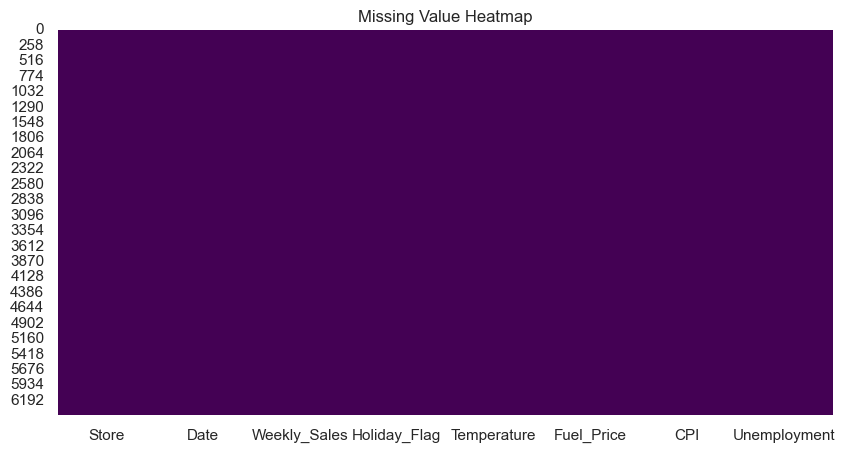

In [108]:
#Visualize Missing Values
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

In [109]:
#Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [110]:
#Display the data type of every column.


df.dtypes

Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [111]:
df.dtypes.value_counts()

float64    5
int64      2
str        1
Name: count, dtype: int64

In [112]:
#Calculate memory usage of the dataset.
df.memory_usage(deep=True)

Index              132
Store            51480
Date            379665
Weekly_Sales     51480
Holiday_Flag     51480
Temperature      51480
Fuel_Price       51480
CPI              51480
Unemployment     51480
dtype: int64

In [113]:
memory = df.memory_usage(deep=True).sum()/1024**2

print(f"Memory Usage : {memory:.2f} MB")

Memory Usage : 0.71 MB


In [114]:
#Find the number of unique values in each column.

df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

In [115]:
#Unique Values of Each Feature
for col in df.columns:

    print("="*50)

    print(f"Column : {col}")

    print("Unique Values :", df[col].nunique())

    print(df[col].unique()[:10])

    print()

Column : Store
Unique Values : 45
[ 1  2  3  4  5  6  7  8  9 10]

Column : Date
Unique Values : 143
<StringArray>
['05-02-2010', '12-02-2010', '19-02-2010', '26-02-2010', '05-03-2010',
 '12-03-2010', '19-03-2010', '26-03-2010', '02-04-2010', '09-04-2010']
Length: 10, dtype: str

Column : Weekly_Sales
Unique Values : 6435
[1643690.9  1641957.44 1611968.17 1409727.59 1554806.68 1439541.59
 1472515.79 1404429.92 1594968.28 1545418.53]

Column : Holiday_Flag
Unique Values : 2
[0 1]

Column : Temperature
Unique Values : 3528
[42.31 38.51 39.93 46.63 46.5  57.79 54.58 51.45 62.27 65.86]

Column : Fuel_Price
Unique Values : 892
[2.572 2.548 2.514 2.561 2.625 2.667 2.72  2.732 2.719 2.77 ]

Column : CPI
Unique Values : 2145
[211.0963582 211.2421698 211.2891429 211.3196429 211.3501429 211.3806429
 211.215635  211.0180424 210.8204499 210.6228574]

Column : Unemployment
Unique Values : 349
[8.106 7.808 7.787 7.838 7.742 7.682 7.962 7.866 7.348 7.143]



In [116]:
#Which columns have high cardinality?


high_cardinality = df.nunique().sort_values(ascending=False)

high_cardinality

Weekly_Sales    6435
Temperature     3528
CPI             2145
Fuel_Price       892
Unemployment     349
Date             143
Store             45
Holiday_Flag       2
dtype: int64

In [117]:
#Convert the Date column to datetime format.

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Date"].head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[us]

In [118]:
df["Date"].dtypes

dtype('<M8[us]')

In [119]:
#Create Date Features

df["Year"] = df["Date"].dt.year

In [120]:
df["Month"] = df["Date"].dt.month_name()

In [121]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,February
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,February
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,February
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,February
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,March


In [122]:
#Identify inconsistent values in the dataset.



for col in df.columns:

    print("="*60)

    print(col)

    print(df[col].value_counts().head())

    print()

Store
Store
1    143
2    143
3    143
4    143
5    143
Name: count, dtype: int64

Date
Date
2010-02-05    45
2010-02-12    45
2010-02-19    45
2010-02-26    45
2010-03-05    45
Name: count, dtype: int64

Weekly_Sales
Weekly_Sales
1643690.90    1
1641957.44    1
1611968.17    1
1409727.59    1
1554806.68    1
Name: count, dtype: int64

Holiday_Flag
Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

Temperature
Temperature
50.43    11
67.87    10
72.62     9
76.67     9
70.28     9
Name: count, dtype: int64

Fuel_Price
Fuel_Price
3.638    39
3.630    34
2.771    29
3.891    29
2.720    28
Name: count, dtype: int64

CPI
CPI
126.442065    11
126.496258    11
126.526286    11
126.552286    11
126.578286    11
Name: count, dtype: int64

Unemployment
Unemployment
8.099    78
8.163    56
7.852    56
8.200    52
7.931    52
Name: count, dtype: int64

Year
Year
2011    2340
2010    2160
2012    1935
Name: count, dtype: int64

Month
Month
April     630
July      630
March     585
June 

## PART 3 : DATA CLEANING

1. There are no missing value or null values in the dataSET 

2. That dataset have no any duplicate value that will npt performace removale duplicate value

3. All data have fixed and consistency data type 

4. There no Any coplumn to required change or rename the columns 

In [123]:
#Standardize Text Columns

#If the dataset contains text columns:

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    df[col] = df[col].str.strip().str.title()

In [124]:
df["Quarter"] = df["Date"].dt.quarter

In [125]:
df["Week"] = df["Date"].dt.isocalendar().week

In [126]:
df["Day"] = df["Date"].dt.day_name()

In [127]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter,Week,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,February,1,5,Friday
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,February,1,6,Friday
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,February,1,7,Friday
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,February,1,8,Friday
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,March,1,9,Friday


## PART 4 : UNIVARIATE ANALYSIS

Objective

Analyze each feature separately to understand its distribution, central tendency, spread, skewness, kurtosis, and identify outliers.

In [128]:
num_cols

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='str')

In [129]:
cat_cols

Index(['Month'], dtype='str')

In [130]:
#Generate descriptive statistics for numerical features.


df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [131]:
#Calculate the mean of all numerical features.

mean_values = df[num_cols].mean().sort_values(ascending=False)

mean_values

Weekly_Sales    1.046965e+06
CPI             1.715784e+02
Temperature     6.066378e+01
Store           2.300000e+01
Unemployment    7.999151e+00
Fuel_Price      3.358607e+00
Holiday_Flag    6.993007e-02
dtype: float64

In [132]:
median_value = df[num_cols].median().sort_values(ascending=False)
median_value

Weekly_Sales    960746.040000
CPI                182.616521
Temperature         62.670000
Store               23.000000
Unemployment         7.874000
Fuel_Price           3.445000
Holiday_Flag         0.000000
dtype: float64

In [133]:
#Find the mode of all numerical features.

mode_values = df[num_cols].mode().iloc[0]

mode_values

Store                1.000
Weekly_Sales    209986.250
Holiday_Flag         0.000
Temperature         50.430
Fuel_Price           3.638
CPI                126.064
Unemployment         8.099
Name: 0, dtype: float64

In [134]:
#Calculate the variance.

variance = df[num_cols].var().sort_values(ascending=False)

variance

Weekly_Sales    3.185097e+11
CPI             1.548951e+03
Temperature     3.402155e+02
Store           1.686929e+02
Unemployment    3.518944e+00
Fuel_Price      2.106991e-01
Holiday_Flag    6.504996e-02
dtype: float64

In [135]:
#Calculate the standard deviation.

std_dev = df[num_cols].std().sort_values(ascending=False)

std_dev

Weekly_Sales    564366.622054
CPI                 39.356712
Temperature         18.444933
Store               12.988182
Unemployment         1.875885
Fuel_Price           0.459020
Holiday_Flag         0.255049
dtype: float64

In [136]:
#Measure skewness for numerical variables.

skewness = df[num_cols].skew().sort_values(ascending=False)

skewness

Holiday_Flag    3.373499
Unemployment    1.188144
Weekly_Sales    0.668362
CPI             0.063492
Store           0.000000
Fuel_Price     -0.096158
Temperature    -0.336768
dtype: float64

In [137]:
#Measure kurtosis for numerical variables.

kurtosis = df[num_cols].kurt().sort_values(ascending=False)

kurtosis

Holiday_Flag    9.383410
Unemployment    2.639712
Weekly_Sales    0.053141
Temperature    -0.612801
Fuel_Price     -1.177378
Store          -1.201187
CPI            -1.839813
dtype: float64

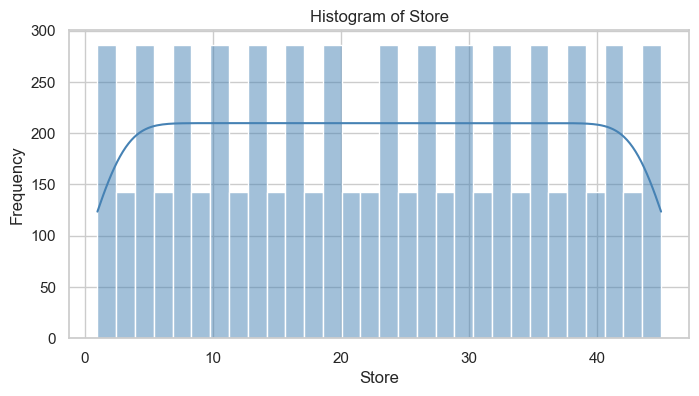

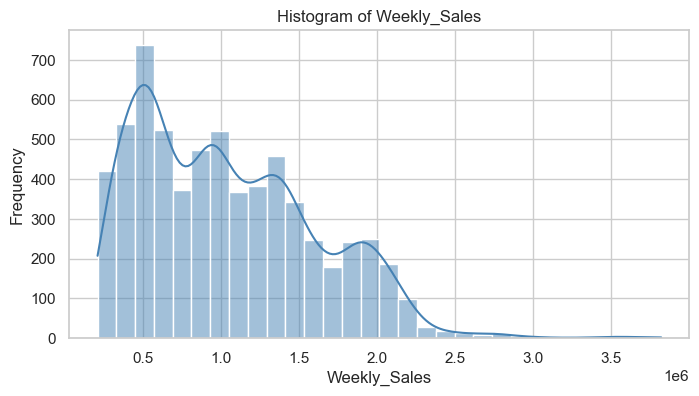

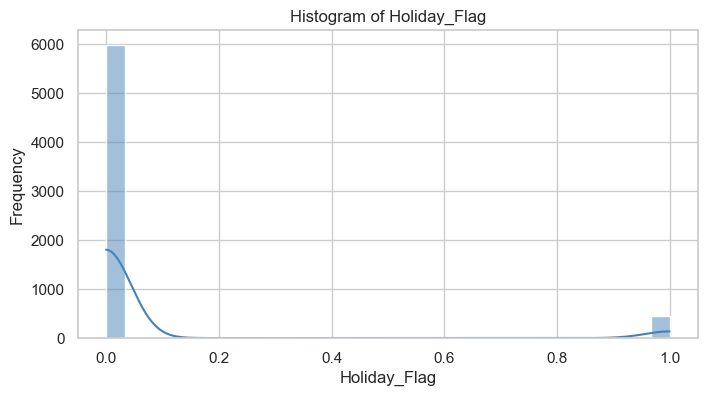

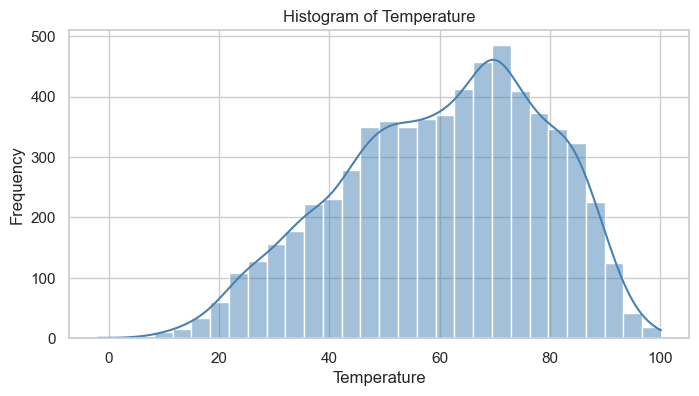

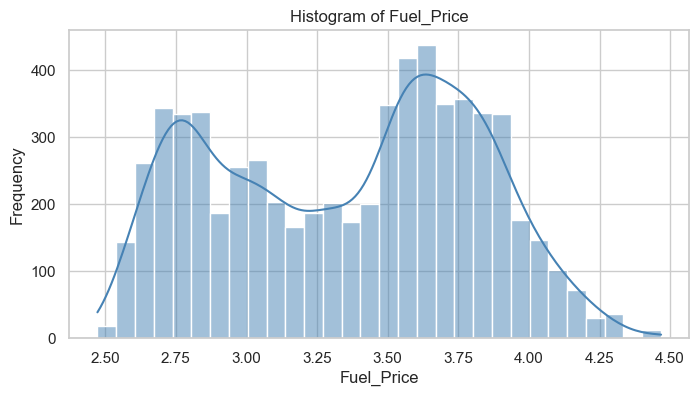

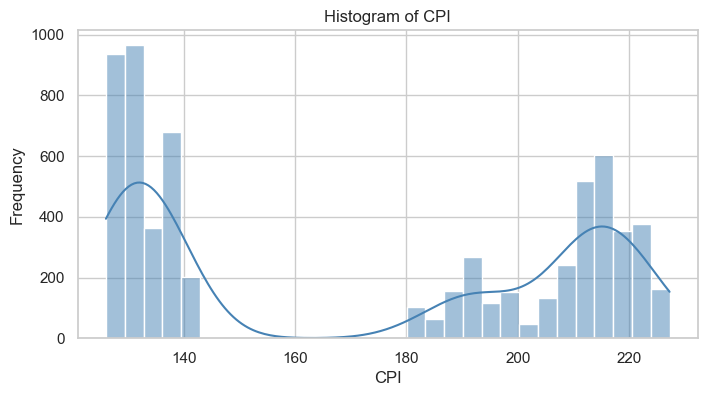

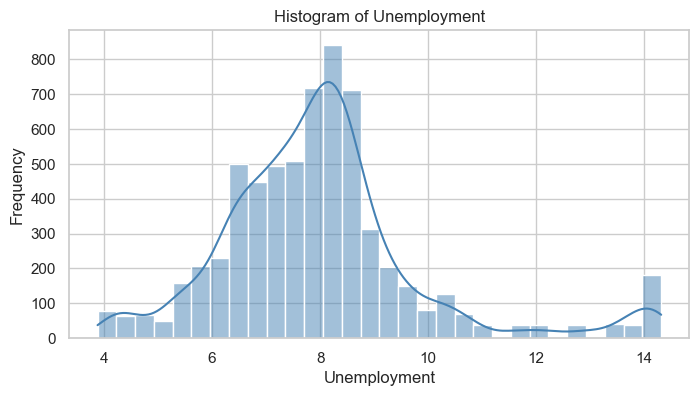

In [138]:
#Plot histograms for all numerical columns.

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=30, kde=True, color="steelblue")

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

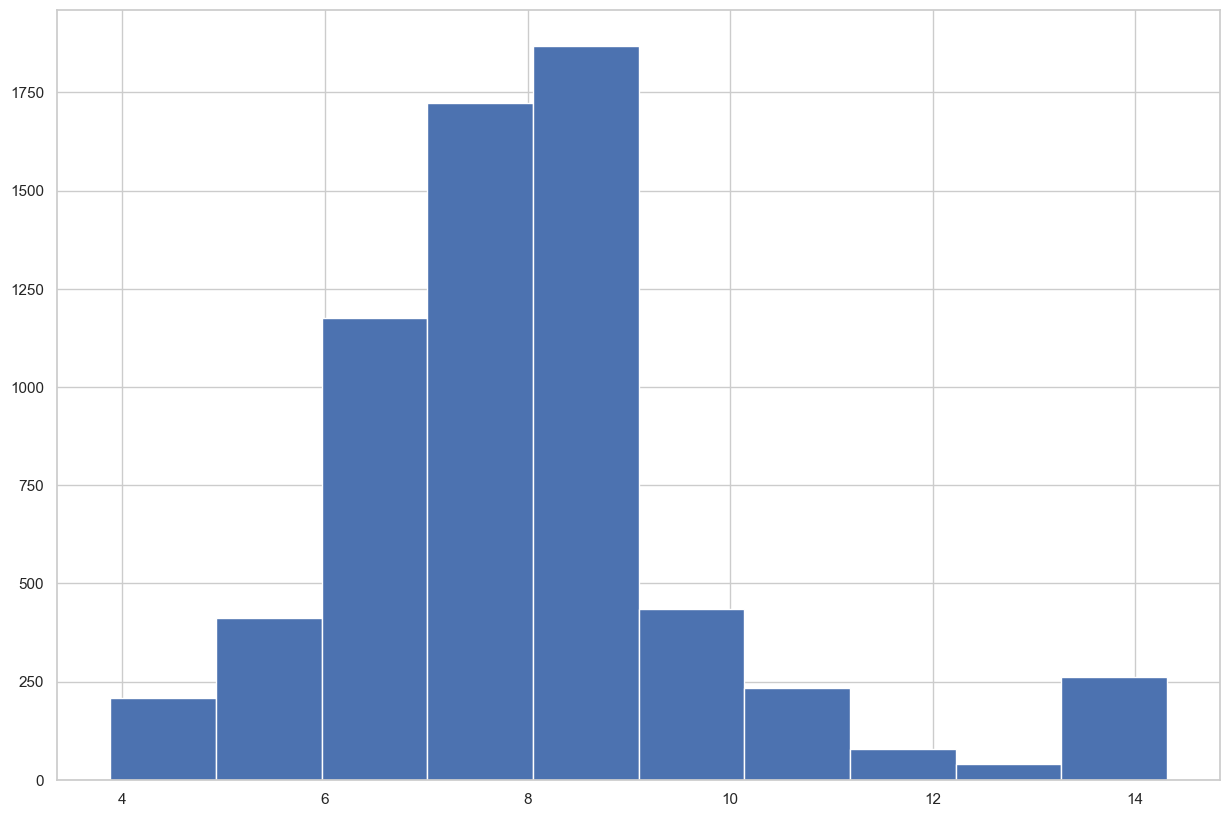

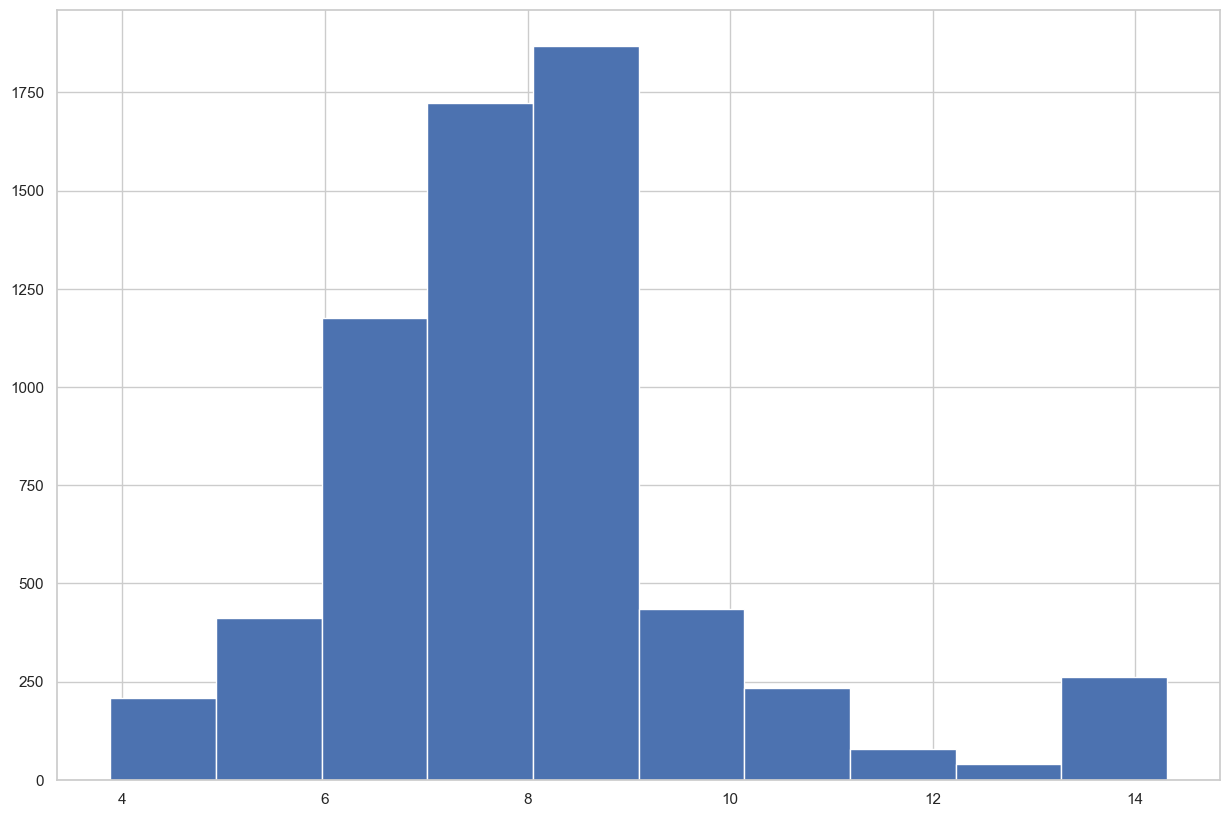

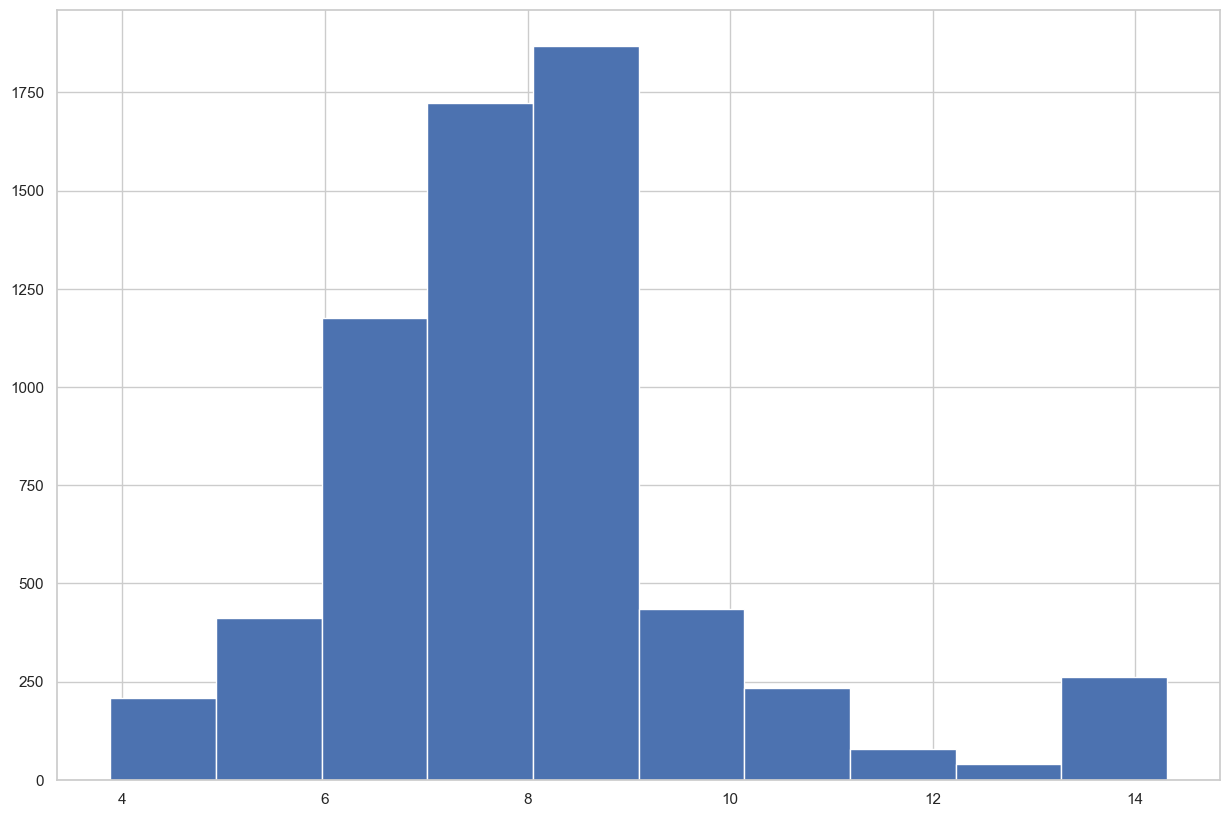

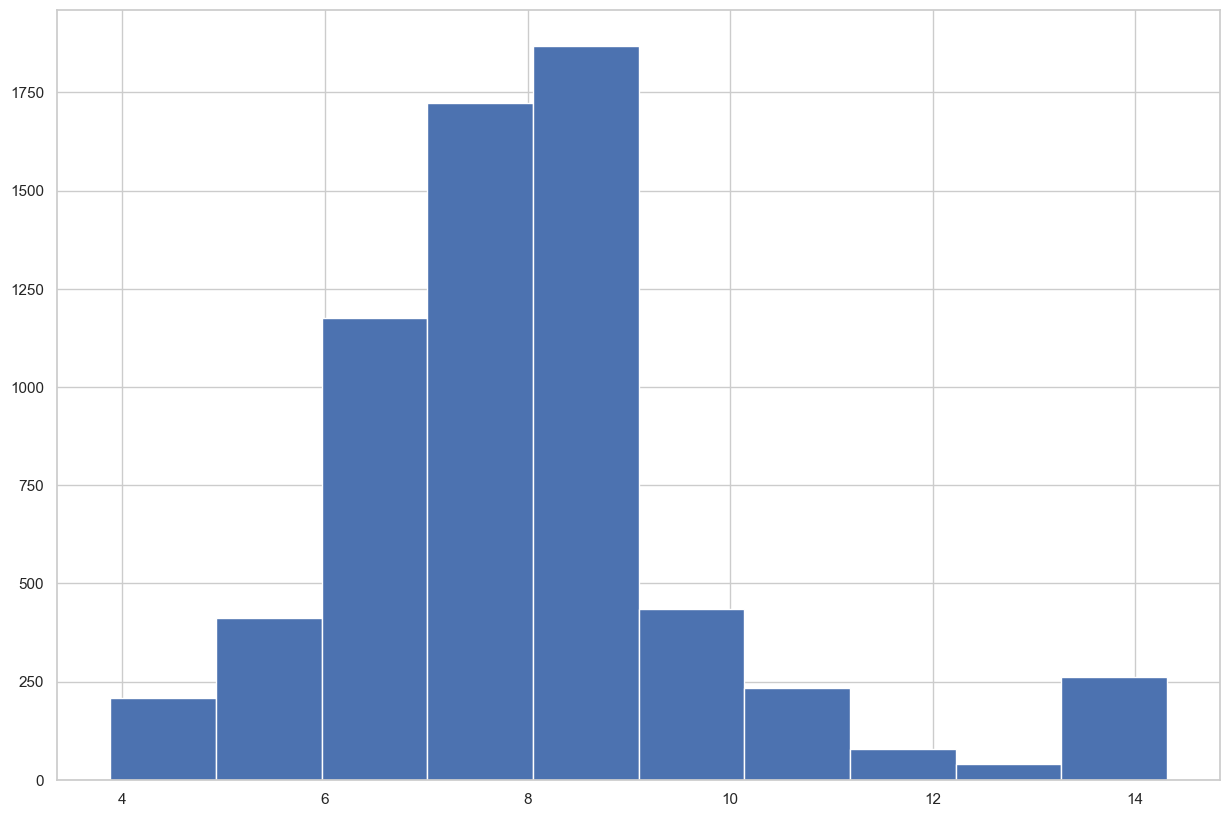

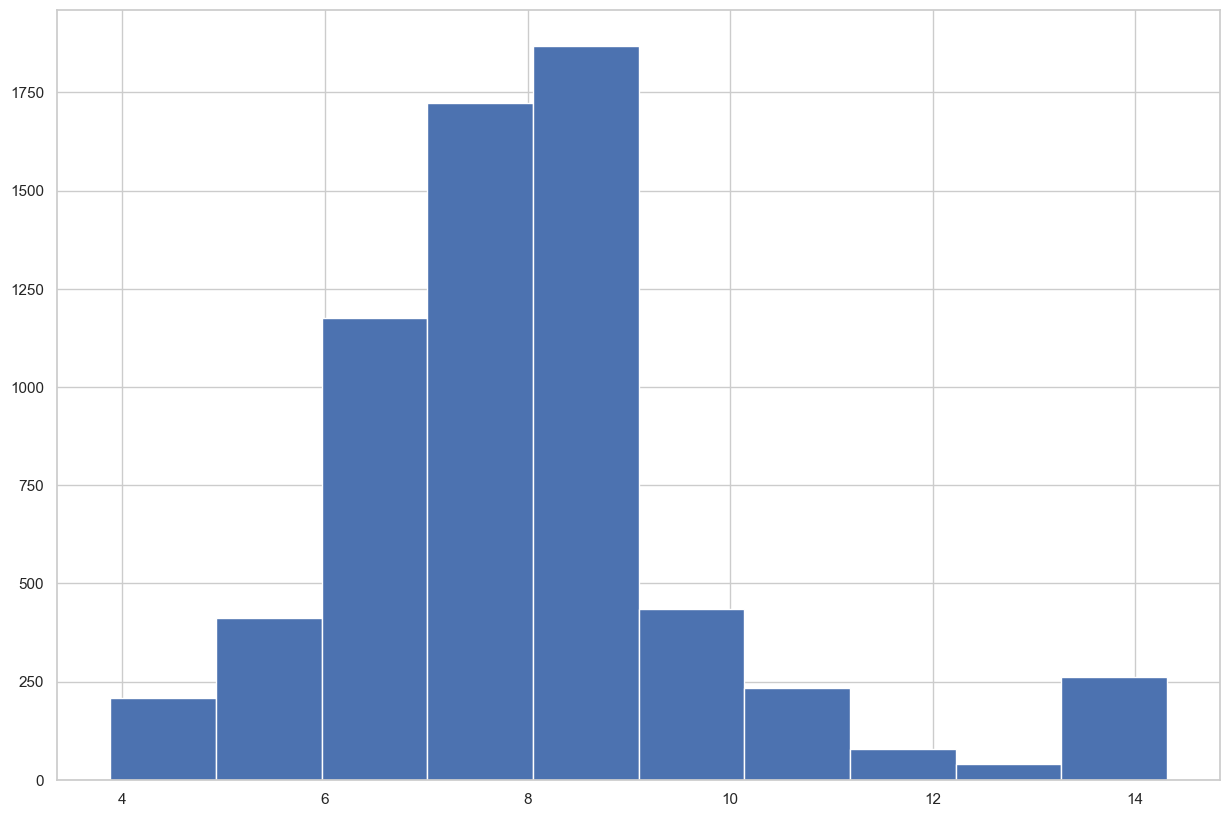

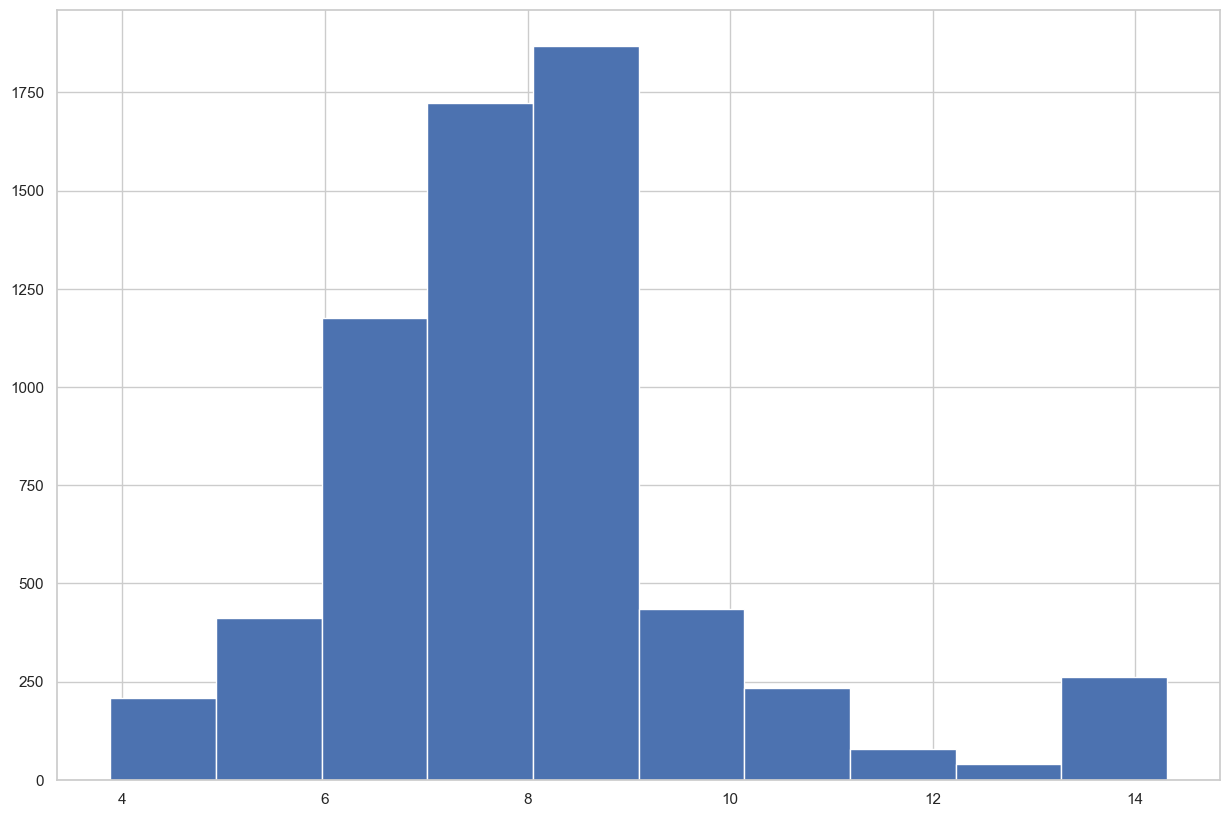

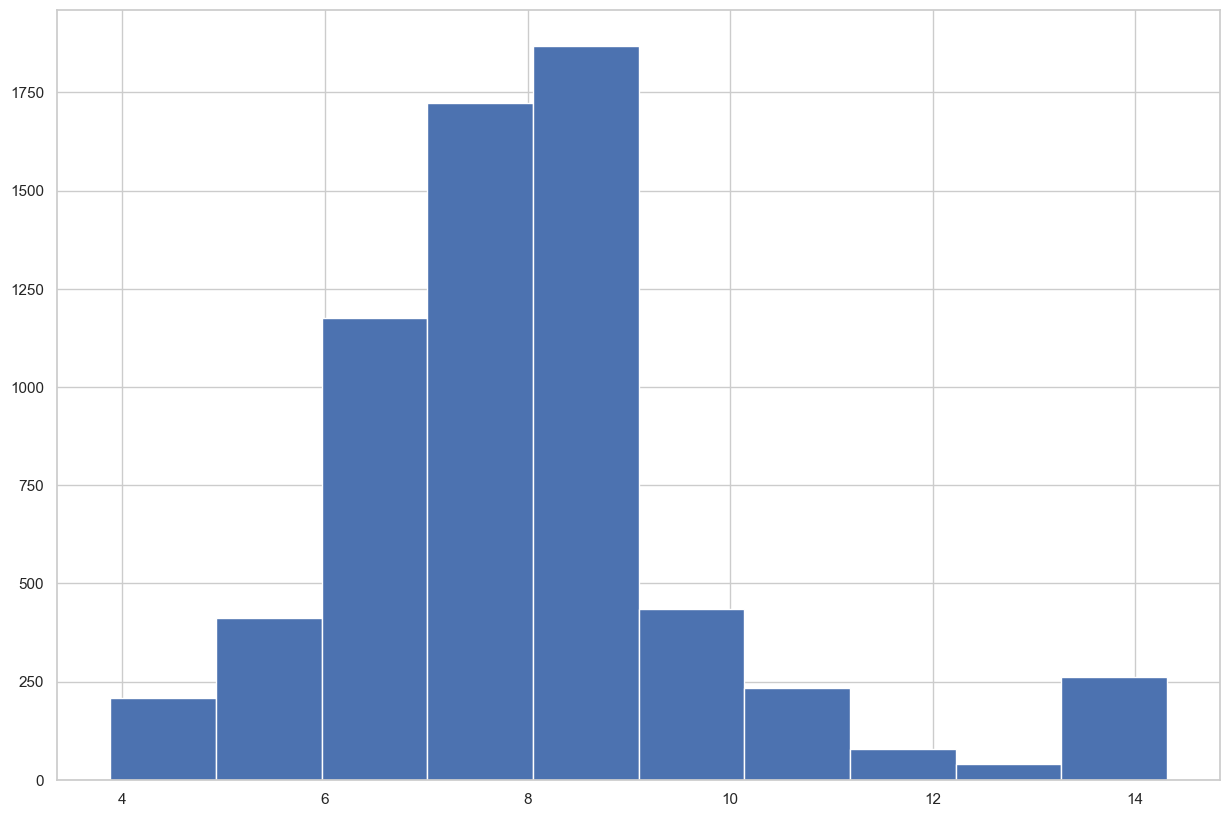

In [139]:
# check one column at the time and analysis the one by one using hoistogram graph

# Numerical cal analysis 

for cal in num_cols:
    
    plt.figure(figsize=(15,10))
    plt.hist(df[col])
    plt.show()

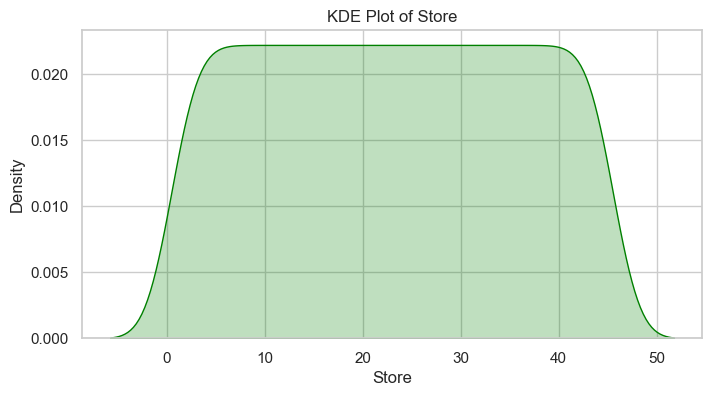

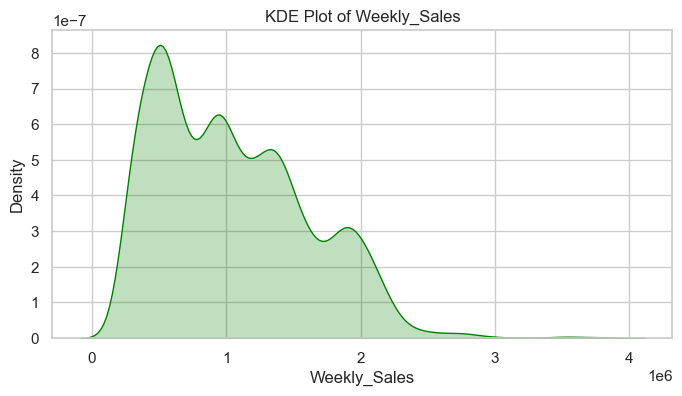

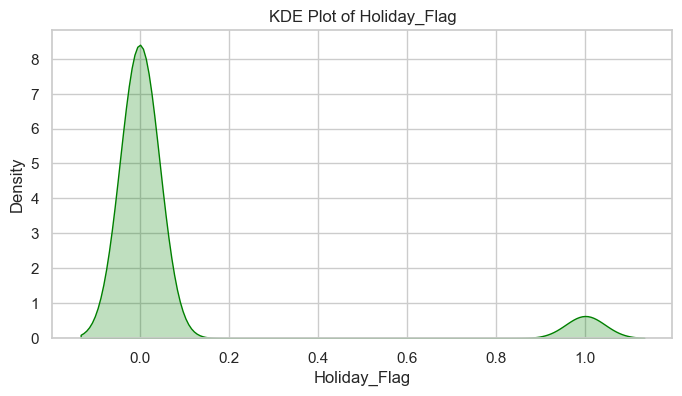

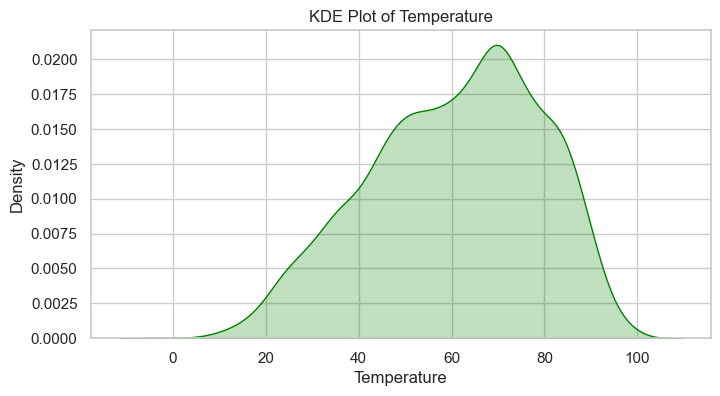

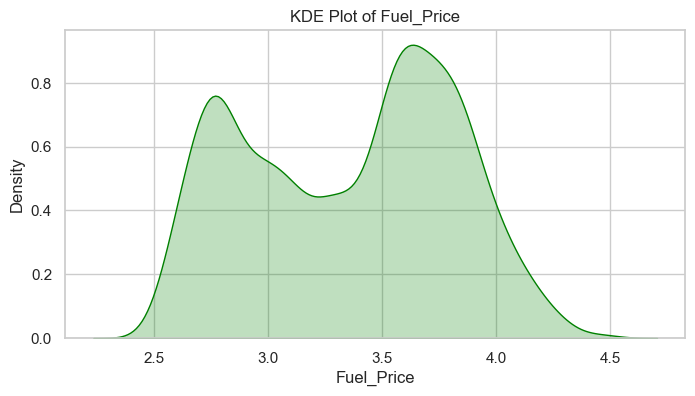

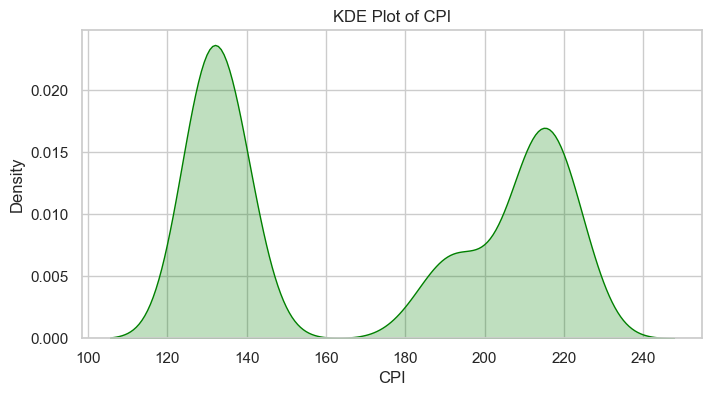

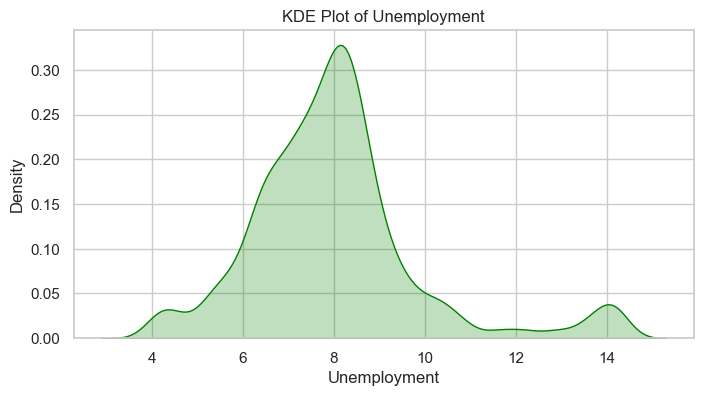

In [140]:
#Visualize the probability density distribution.

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.kdeplot(df[col], fill=True, color="green")

    plt.title(f"KDE Plot of {col}")

    plt.xlabel(col)

    plt.show()

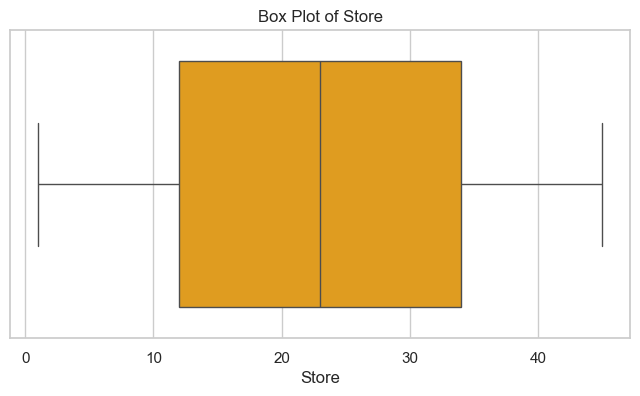

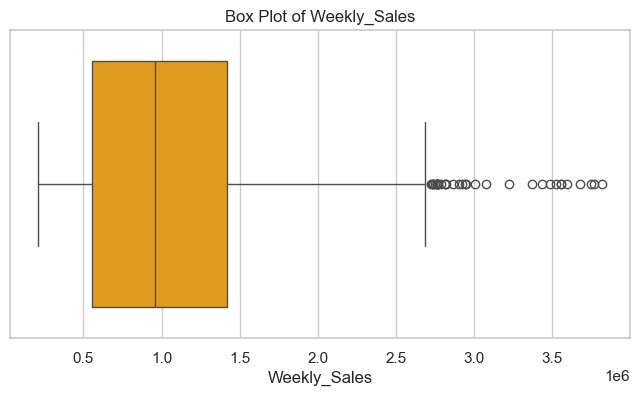

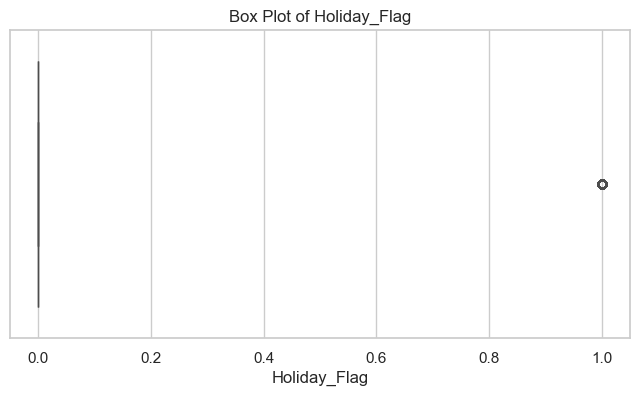

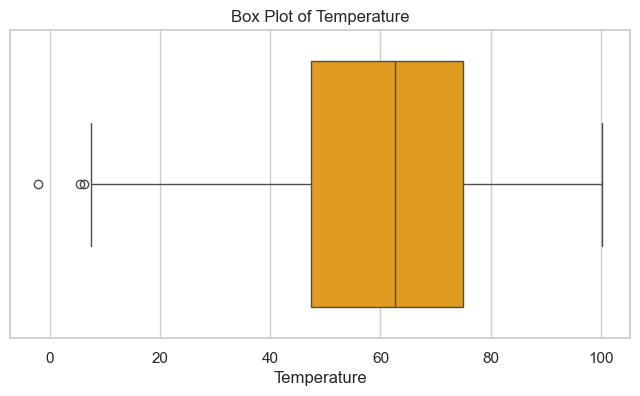

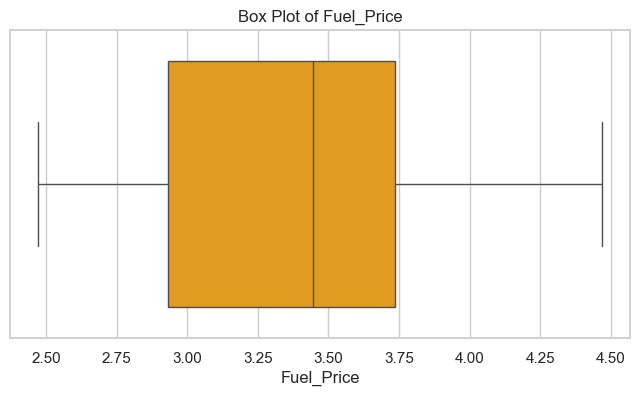

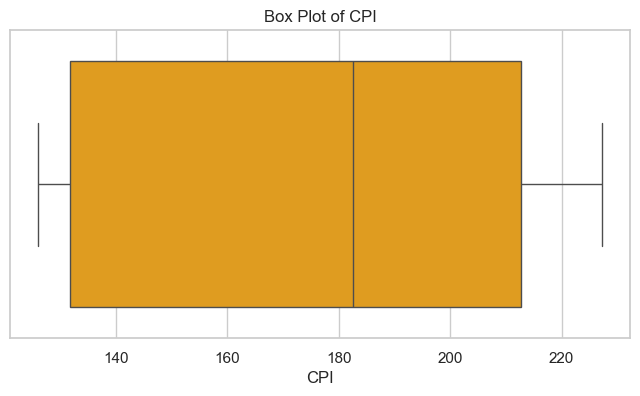

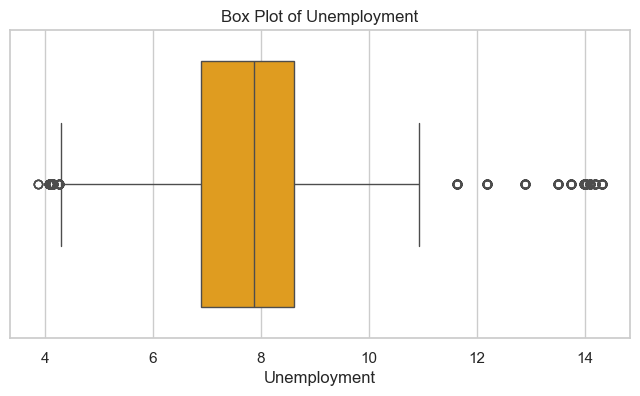

In [141]:
#dentify outliers using boxplots.

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col], color="orange")

    plt.title(f"Box Plot of {col}")

    plt.xlabel(col)

    plt.show()

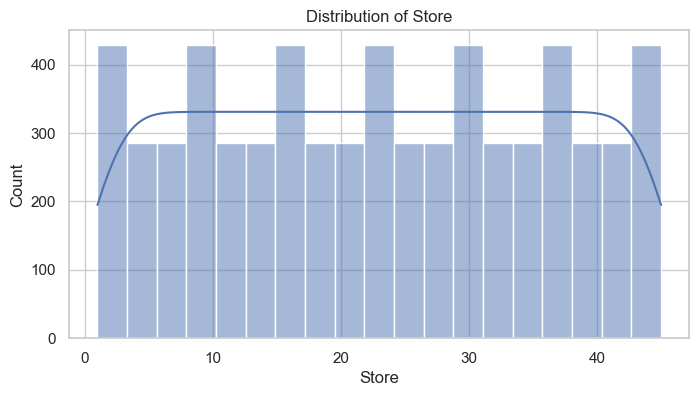

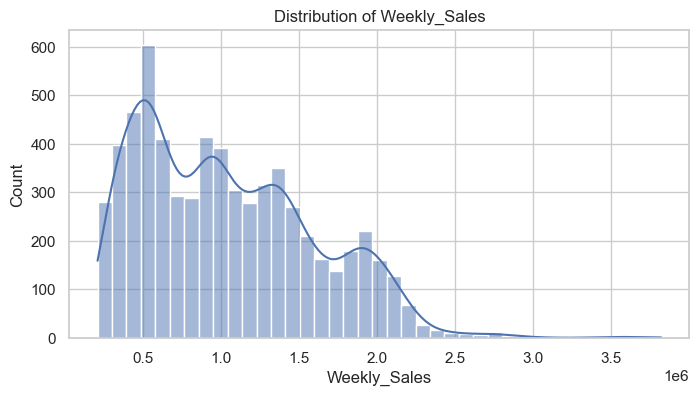

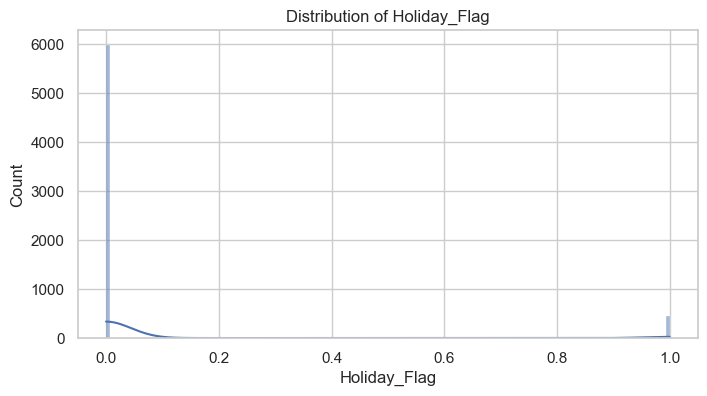

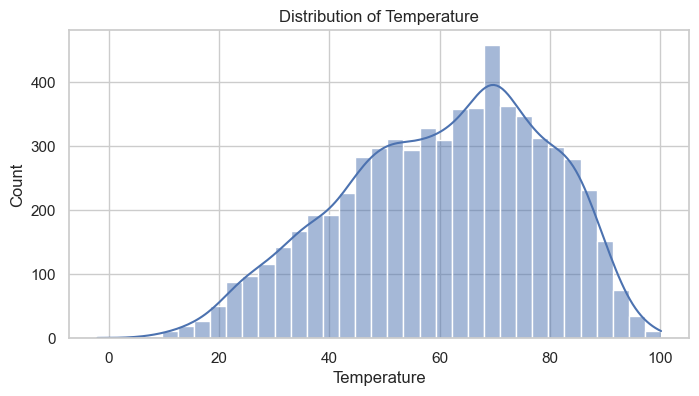

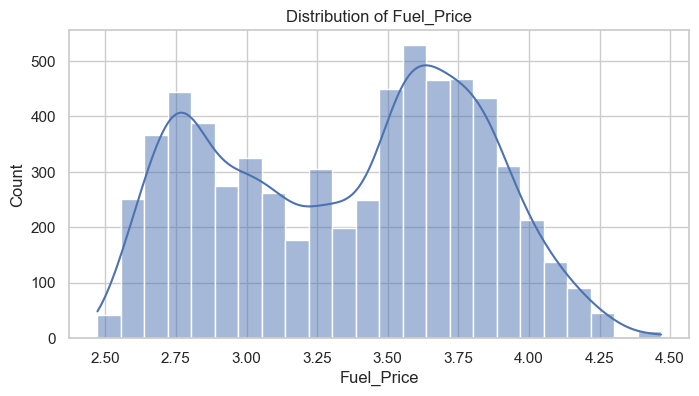

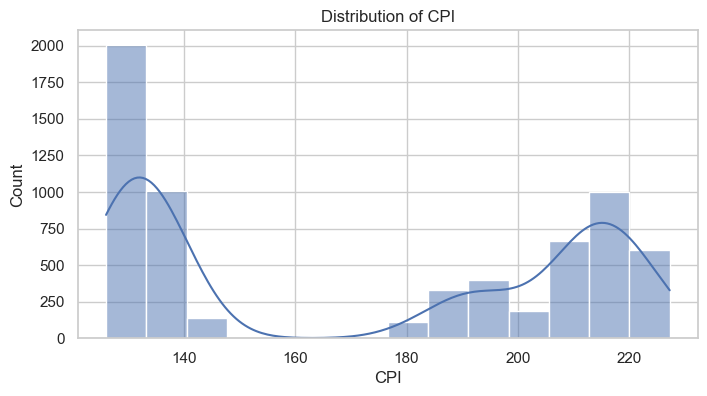

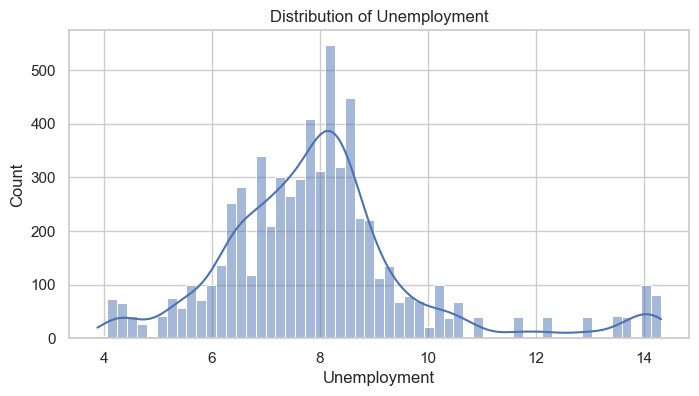

In [142]:
#Analyze feature distributions.

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.show()

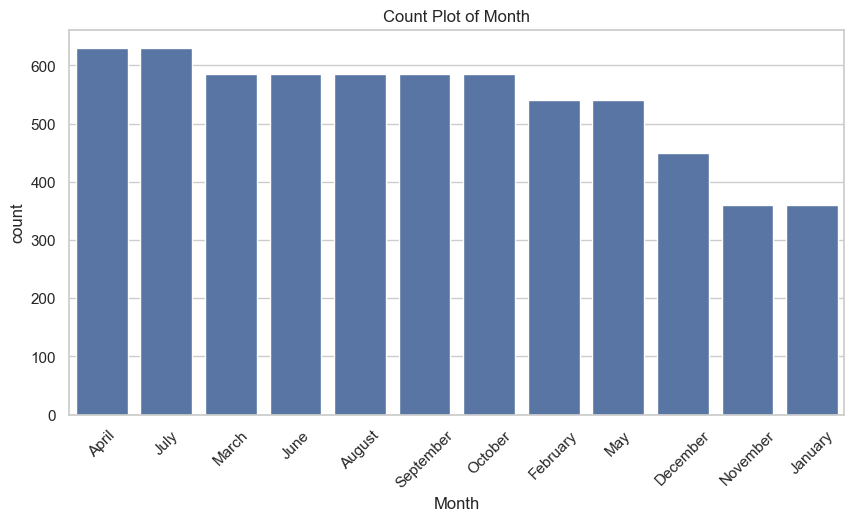

In [143]:
#Display the frequency of categorical variables.

for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}")

    plt.xticks(rotation=45)

    plt.show()

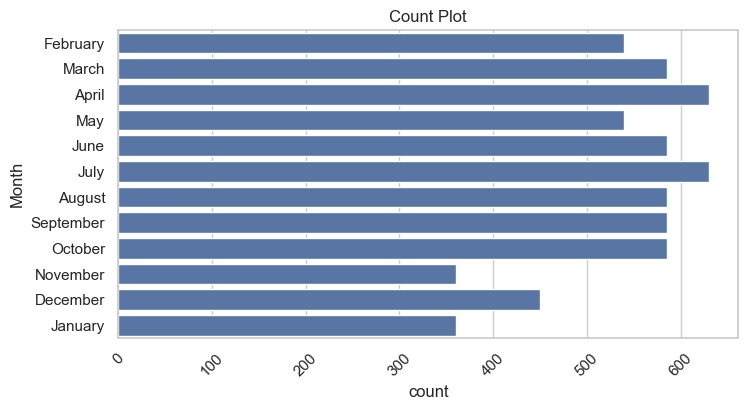

In [144]:
for cal in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(df[col], fill = True,)
    plt.title(f"Count Plot")

    plt.xticks(rotation=45)

    plt.show()

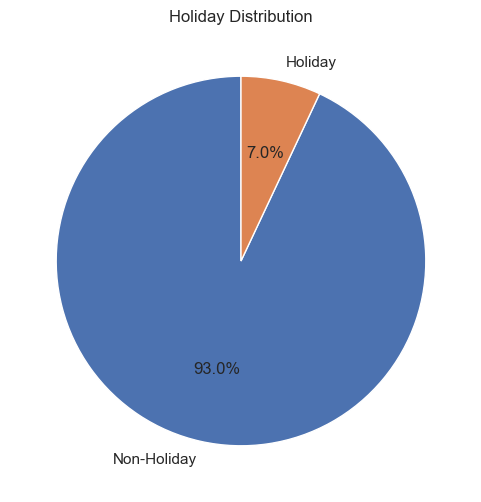

In [145]:
#Show the distribution of holiday and non-holiday weeks.

holiday_counts = df["Holiday_Flag"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    holiday_counts,
    labels=["Non-Holiday","Holiday"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Holiday Distribution")

plt.show()

In [146]:
cat_cols

Index(['Month'], dtype='str')

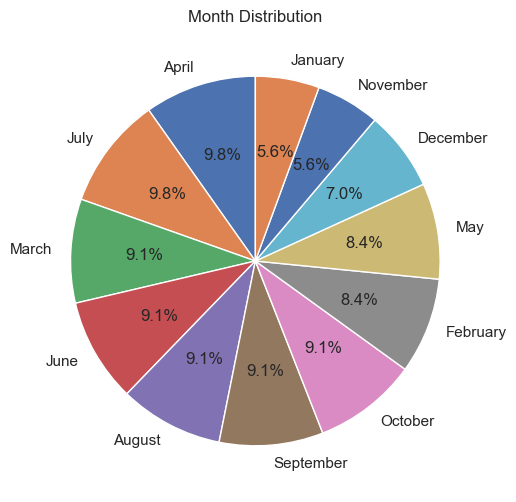

In [147]:
for cal in cat_cols:
    plt.figure(figsize=(6,6))
    df[cal].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(f"{cal} Distribution")
    plt.ylabel("")  # remove y-label
    plt.show()


In [148]:
#Display frequency tables for categorical variables.

print(df["Holiday_Flag"].value_counts())

print()

print(df["Month"].value_counts())

Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

Month
April        630
July         630
March        585
June         585
August       585
September    585
October      585
February     540
May          540
December     450
November     360
January      360
Name: count, dtype: int64


## PART 5 : BIVARIATE ANALYSIS

Objective: Analyze the relationship between two variables to understand how one variable affects another and generate business insights.

In [149]:
#Calculate the correlation among numerical variables.
corr = df[num_cols].corr()
corr

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


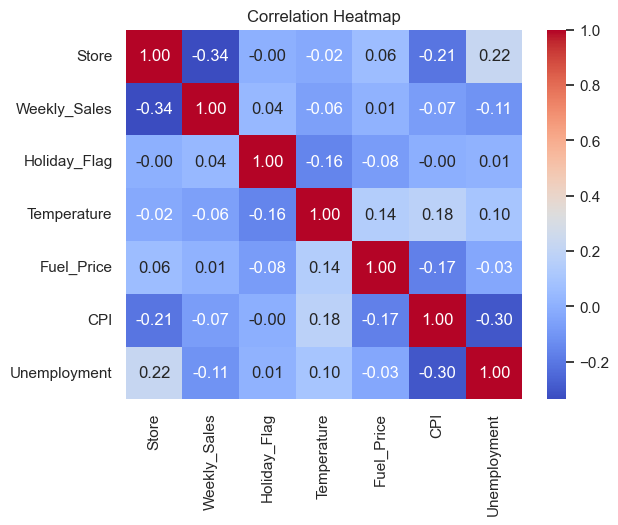

In [150]:
plt.Figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

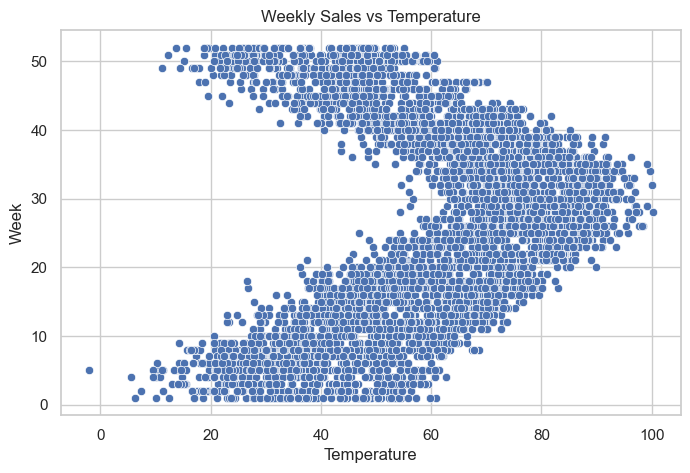

In [154]:
#Analyze the relationship between Weekly Sales and Temperature.


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Week"
)

plt.title("Weekly Sales vs Temperature")

plt.show()

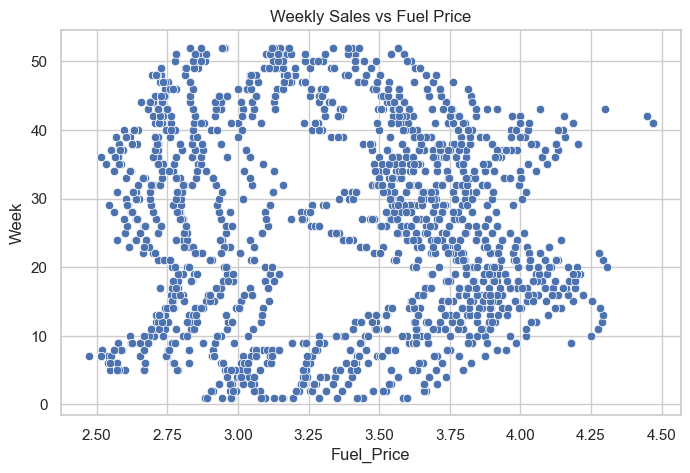

In [157]:
#Analyze the relationship between Weekly Sales and Fuel Price.


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Fuel_Price",
    y="Week"
)

plt.title("Weekly Sales vs Fuel Price")

plt.show()

SyntaxError: invalid character '✅' (U+2705) (3489715113.py, line 175)

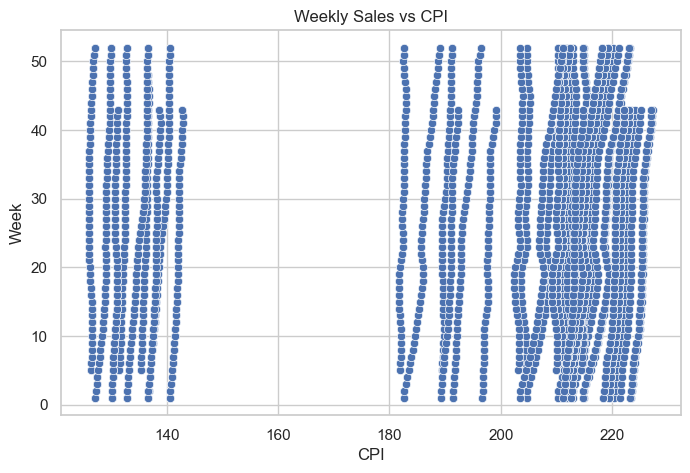

In [160]:
#Analyze the relationship between Weekly Sales and CPI.


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="CPI",
    y="Week"
)

plt.title("Weekly Sales vs CPI")

plt.show()

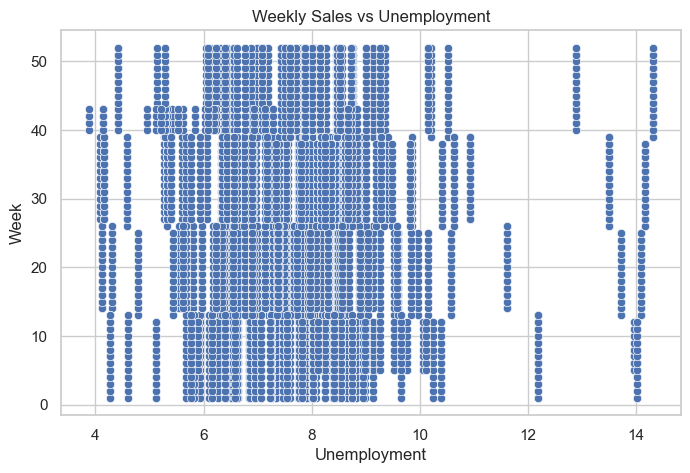

In [162]:
#Analyze the relationship between Weekly Sales and Unemployment.

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Week"
)

plt.title("Weekly Sales vs Unemployment")

plt.show()

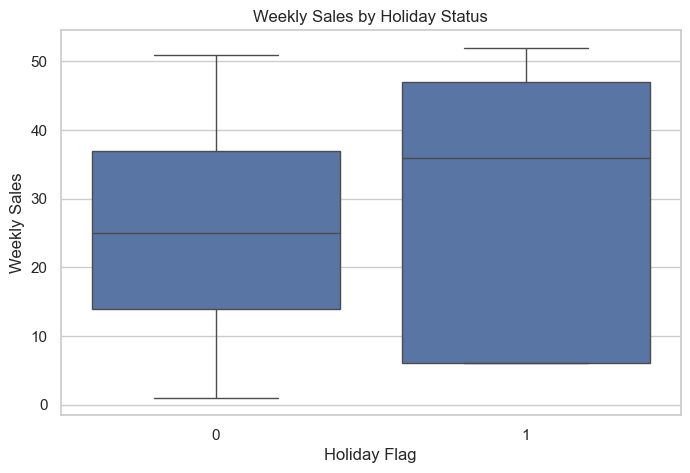

In [163]:
#ompare Weekly Sales during Holiday and Non-Holiday weeks.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Holiday_Flag",
    y="Week"
)

plt.title("Weekly Sales by Holiday Status")

plt.xlabel("Holiday Flag")

plt.ylabel("Weekly Sales")

plt.show()

In [165]:
#ind the average weekly sales for each store.

store_sales = df.groupby("Store")["Week"].mean().sort_values(ascending=False)

store_sales

Store
1     25.818182
2     25.818182
3     25.818182
4     25.818182
5     25.818182
6     25.818182
7     25.818182
8     25.818182
9     25.818182
10    25.818182
11    25.818182
12    25.818182
13    25.818182
14    25.818182
15    25.818182
16    25.818182
17    25.818182
18    25.818182
19    25.818182
20    25.818182
21    25.818182
22    25.818182
23    25.818182
24    25.818182
25    25.818182
26    25.818182
27    25.818182
28    25.818182
29    25.818182
30    25.818182
31    25.818182
32    25.818182
33    25.818182
34    25.818182
35    25.818182
36    25.818182
37    25.818182
38    25.818182
39    25.818182
40    25.818182
41    25.818182
42    25.818182
43    25.818182
44    25.818182
45    25.818182
Name: Week, dtype: Float64

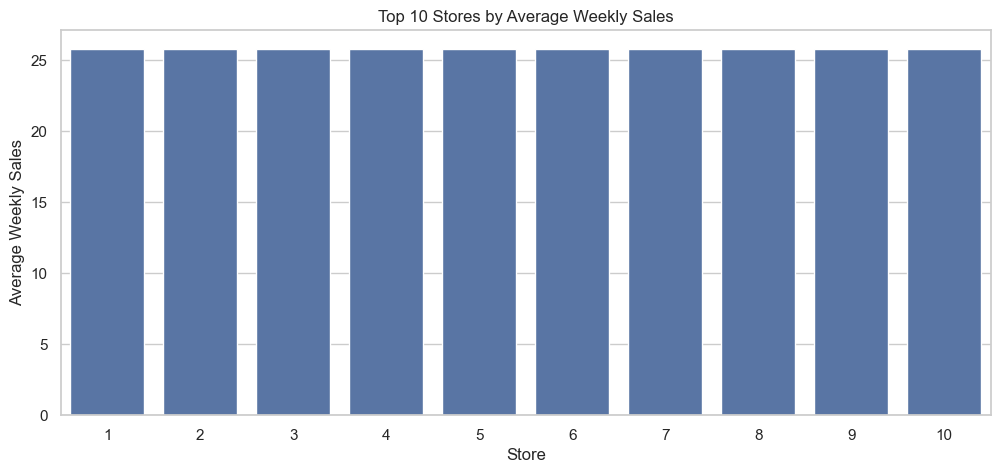

In [166]:
#Identify the top 10 stores based on average weekly sales.

top10 = store_sales.head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 Stores by Average Weekly Sales")

plt.xlabel("Store")

plt.ylabel("Average Weekly Sales")

plt.show()

In [168]:
#Analyze monthly sales trends.


monthly_sales = df.groupby("Month")["Week"].mean()

monthly_sales

Month
April        15.142857
August       32.692308
December          50.0
February           6.5
January            2.5
July         28.142857
June         23.692308
March        10.692308
May               19.5
November          45.5
October      41.307692
September         37.0
Name: Week, dtype: Float64

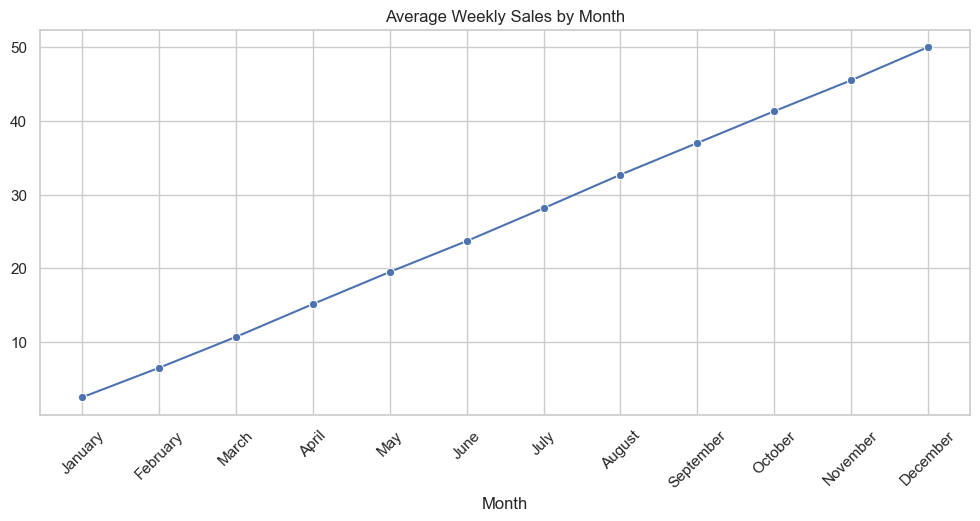

In [169]:
#Better Visualization (Correct Month Order)
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Weekly Sales by Month")

plt.show()

In [171]:
#compare sales across quarters.


quarter_sales = df.groupby("Quarter")["Week"].mean()

quarter_sales

Quarter
1     7.181818
2    19.333333
3         32.5
4    45.193548
Name: Week, dtype: Float64

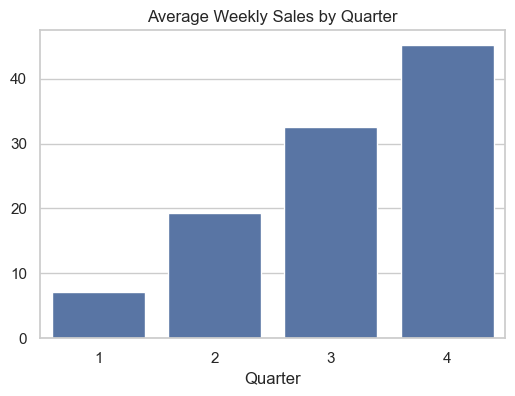

In [172]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=quarter_sales.index,
    y=quarter_sales.values
)

plt.title("Average Weekly Sales by Quarter")

plt.show()

## PART 6 : MULTIVARIATE ANALYSIS
Objective

Analyze how multiple variables together influence Weekly Sales and identify hidden business trends.

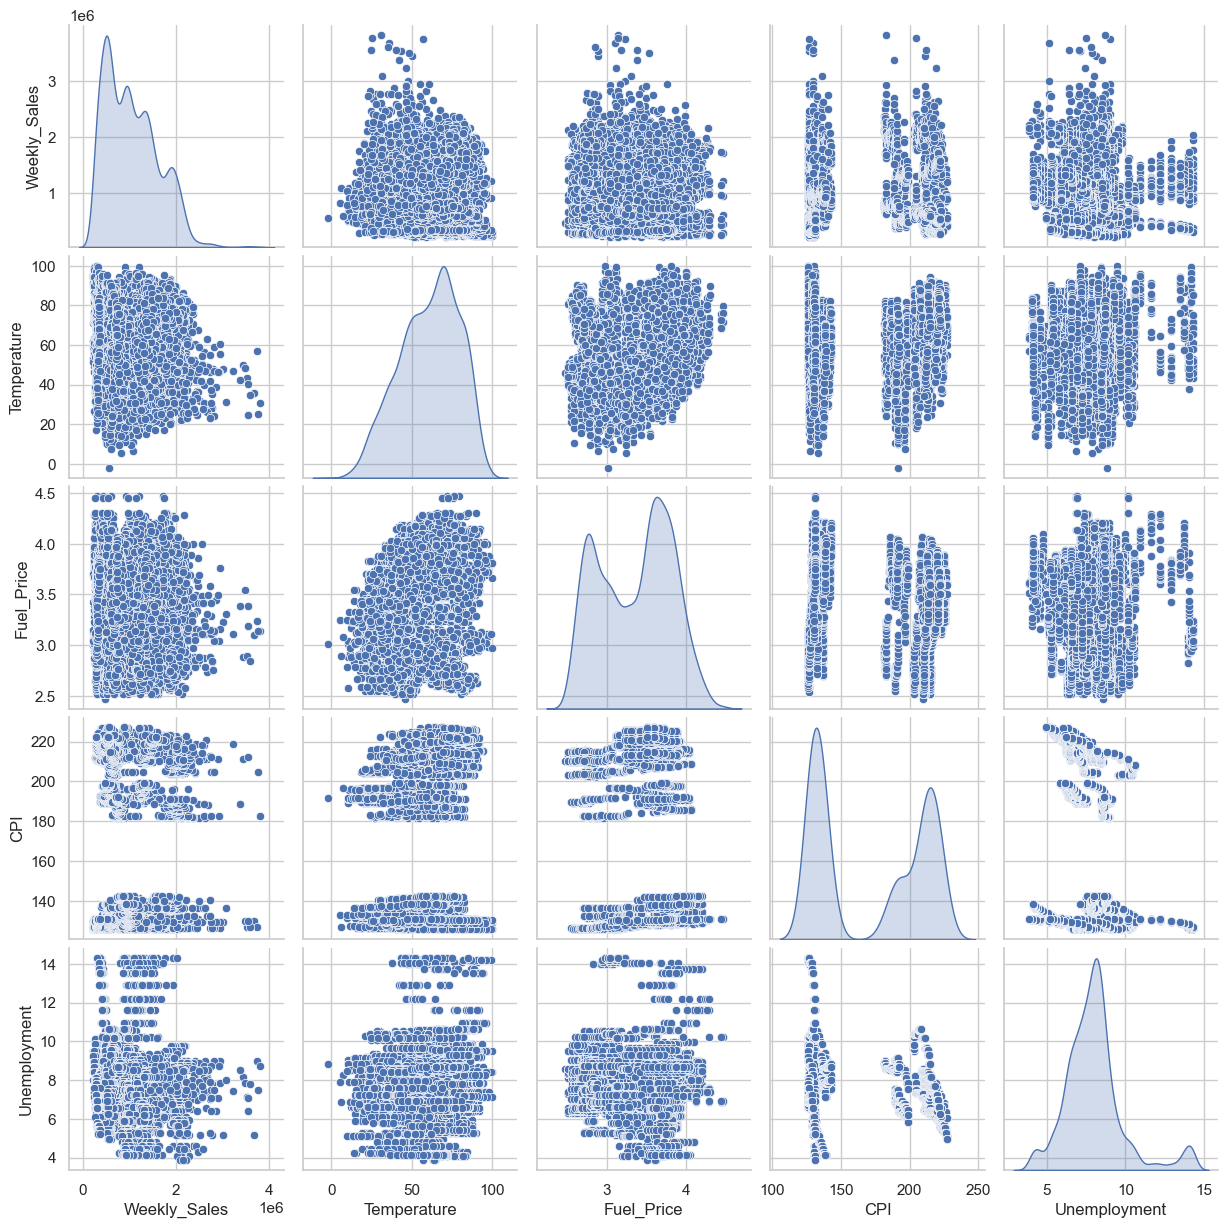

In [184]:
#Visualize relationships among important numerical variables.

selected_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

sns.pairplot(
    df[selected_cols],
    diag_kind="kde"
)

plt.show()

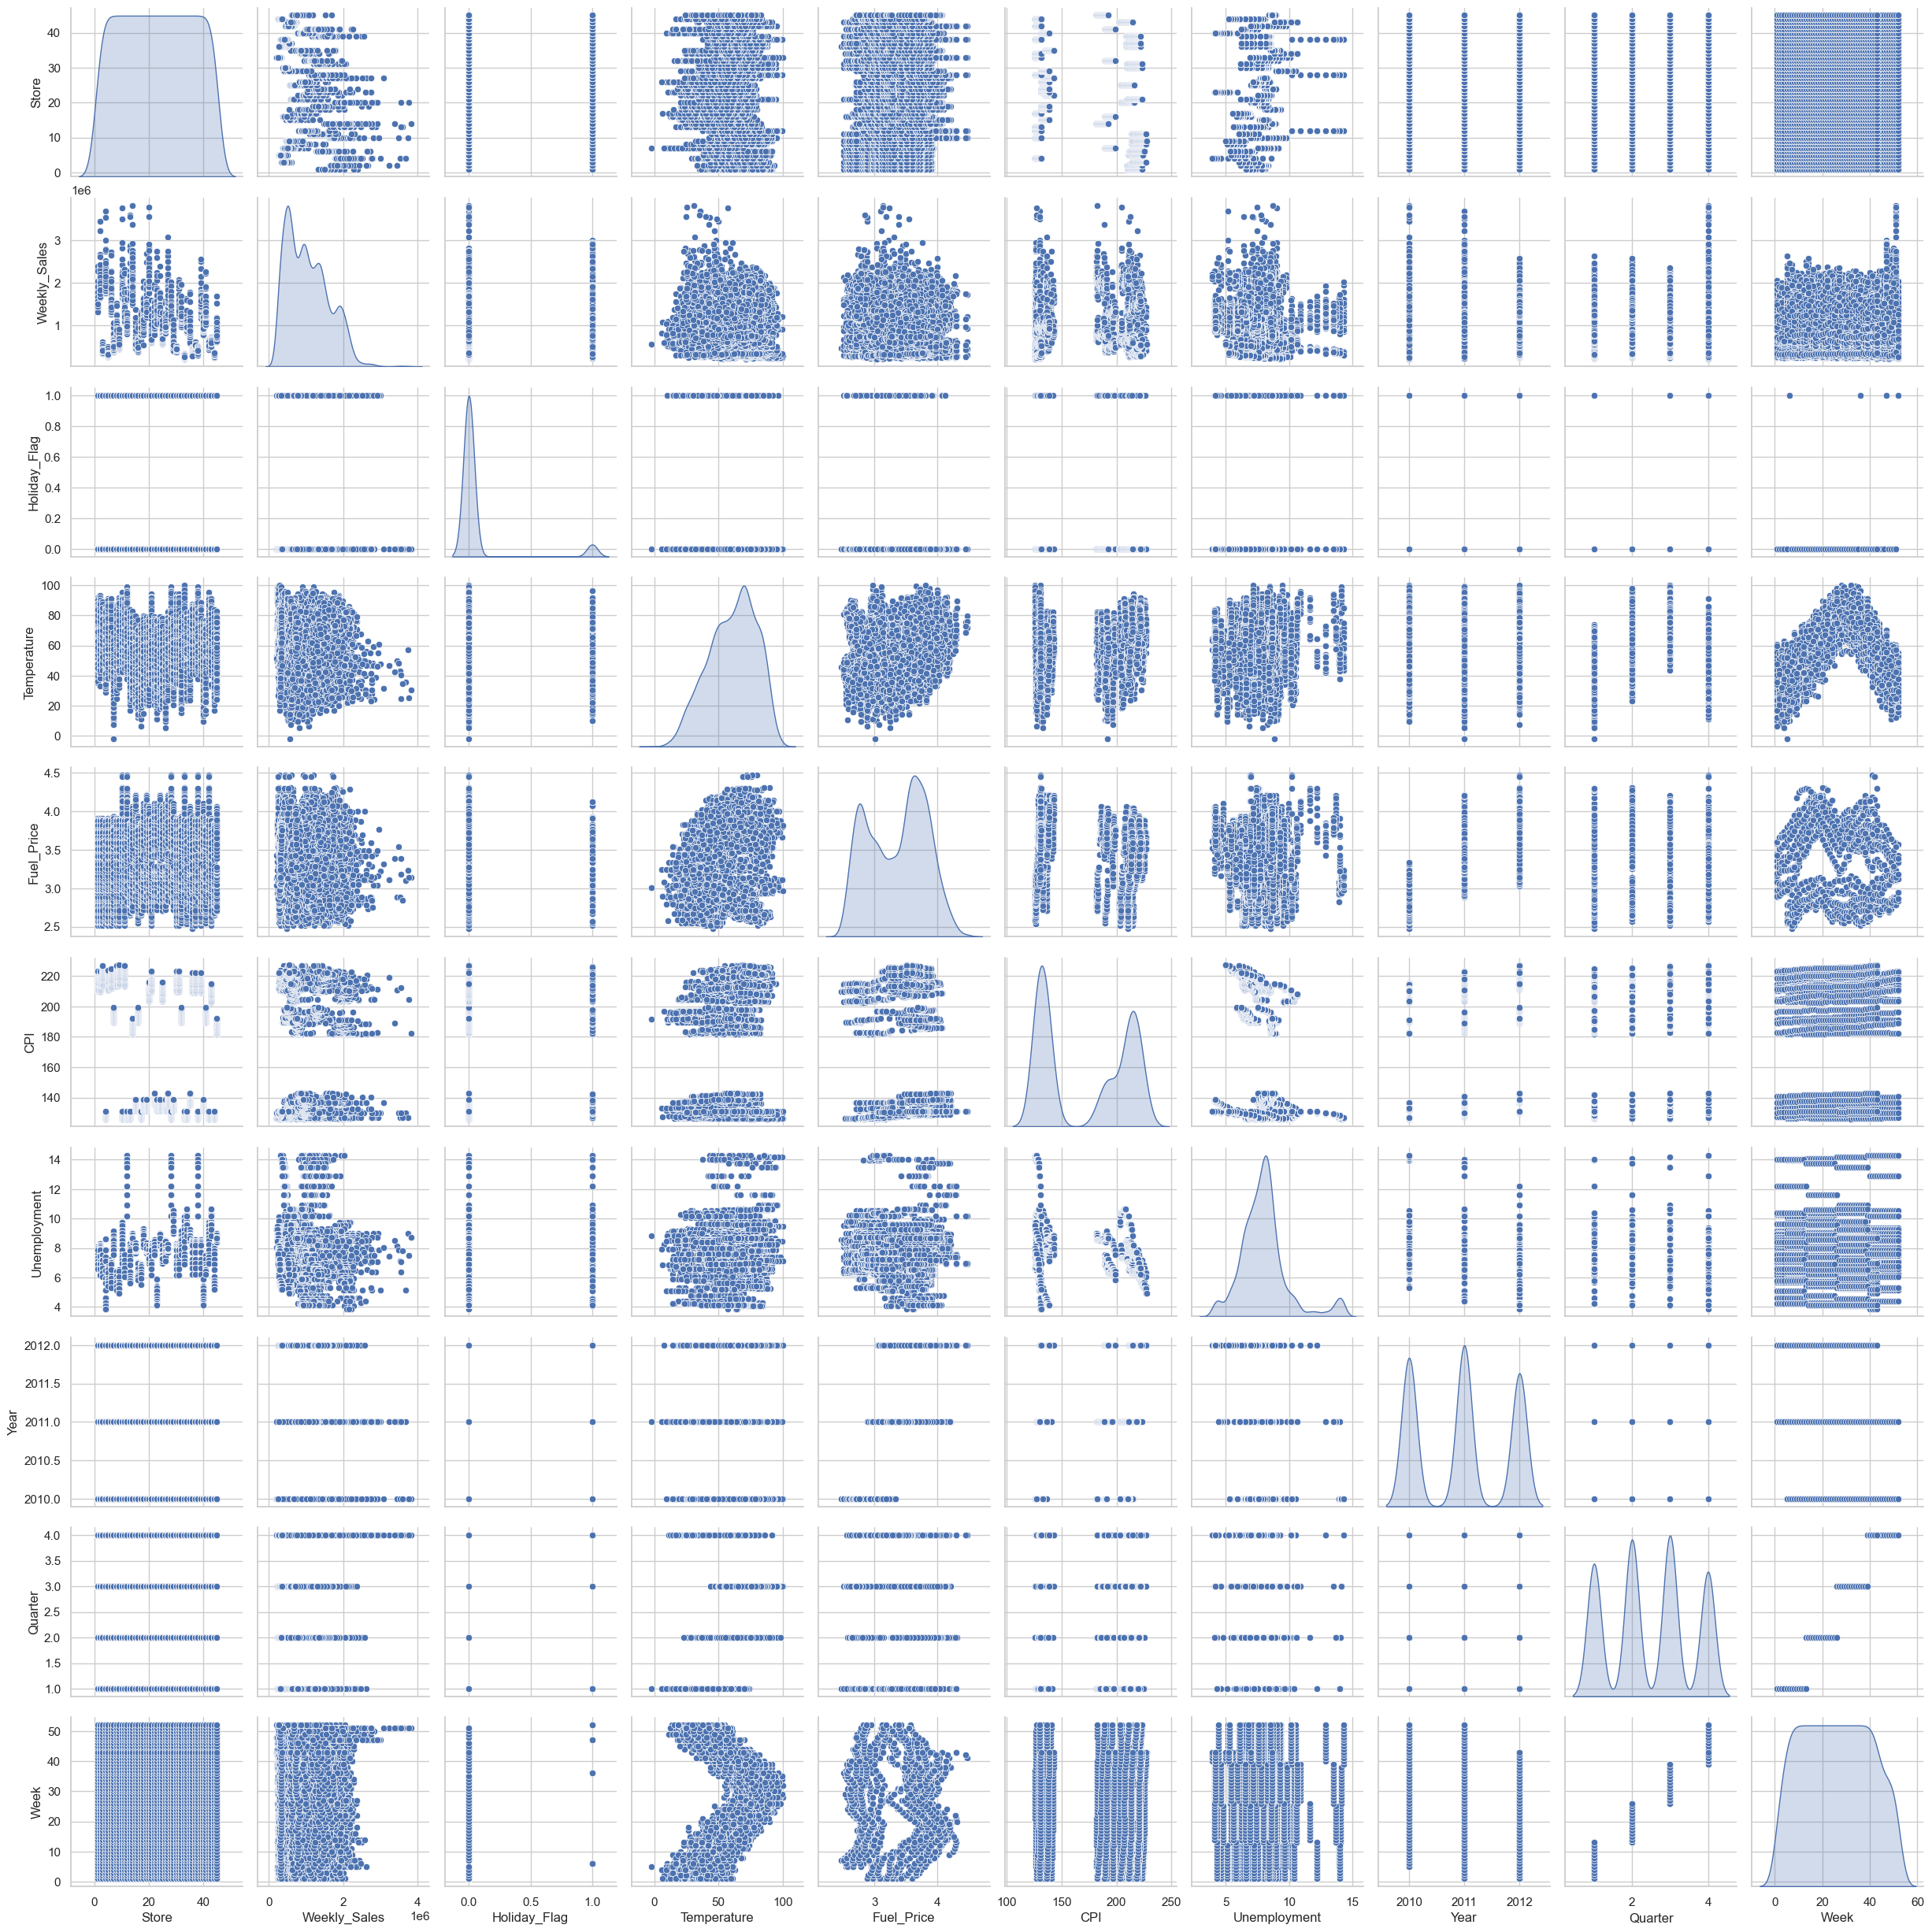

In [177]:
plt.Figure(figsize=(10,15))
sns.pairplot(df,diag_kind='kde')
plt.show()

In [181]:
num_cols

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='str')

In [182]:
#Find which variables influence Weekly Sales the most.

sales_corr = (
    df[num_cols].corr()["Weekly_Sales"]
    .sort_values(ascending=False)
)

sales_corr

Weekly_Sales    1.000000
Holiday_Flag    0.036891
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64

In [183]:
top3 = (
    sales_corr
    .drop("Weekly_Sales")
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

top3

Store           0.335332
Unemployment    0.106176
CPI             0.072634
Name: Weekly_Sales, dtype: float64

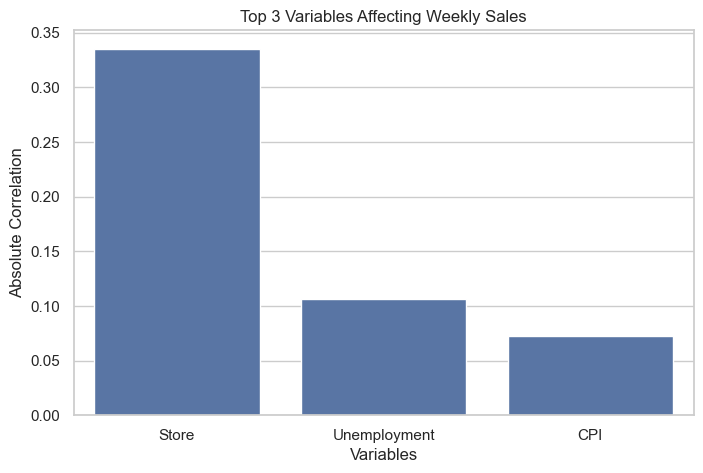

In [185]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top3.index,
    y=top3.values
)

plt.title("Top 3 Variables Affecting Weekly Sales")

plt.xlabel("Variables")

plt.ylabel("Absolute Correlation")

plt.show()

In [188]:
#Compare average Weekly Sales by Store and Holiday Flag.

store_holiday = pd.pivot_table(

    df,

    values="Weekly_Sales",

    index="Store",

    columns="Holiday_Flag",

    aggfunc="mean"

)

store_holiday.head()

Holiday_Flag,0,1
Store,,
1,1.546957e+06,1665747.656
2,1.914209e+06,2079266.900
3,4.000648e+05,437811.050
4,2.083556e+06,2243102.624
5,3.148923e+05,359501.607


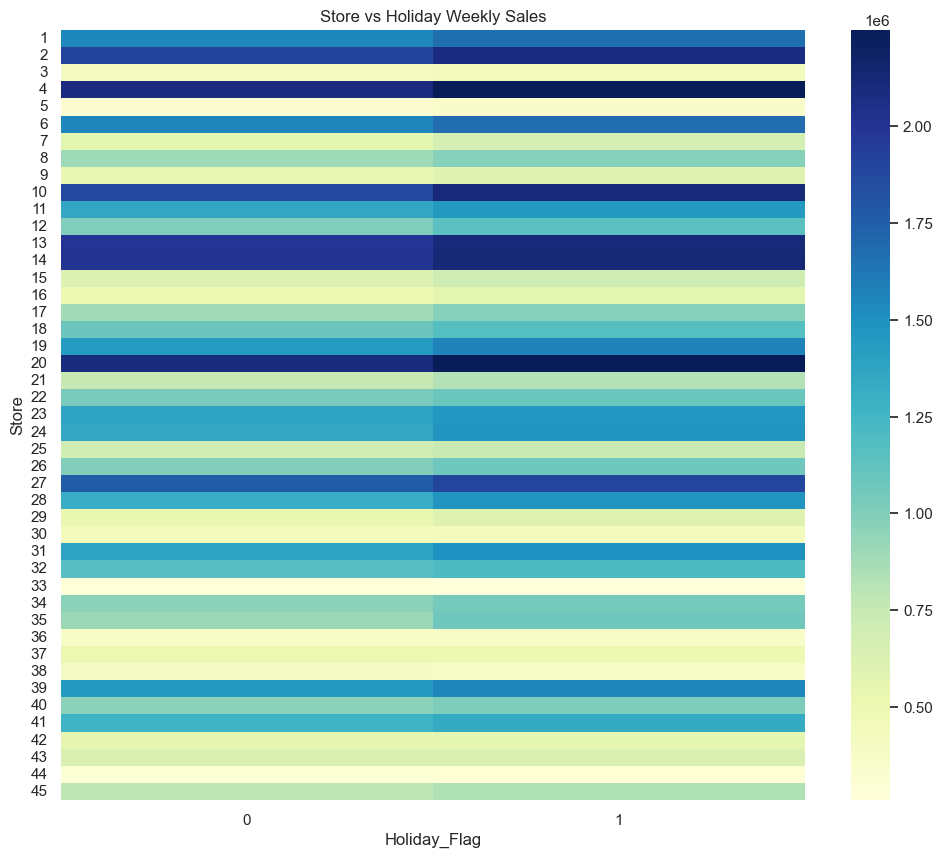

In [189]:
plt.figure(figsize=(12,10))

sns.heatmap(

    store_holiday,

    cmap="YlGnBu"

)

plt.title("Store vs Holiday Weekly Sales")

plt.show()

In [190]:
#Analyze yearly sales performance.

year_sales = df.groupby("Year")["Weekly_Sales"].mean()

year_sales

Year
2010    1.059670e+06
2011    1.046239e+06
2012    1.033660e+06
Name: Weekly_Sales, dtype: float64

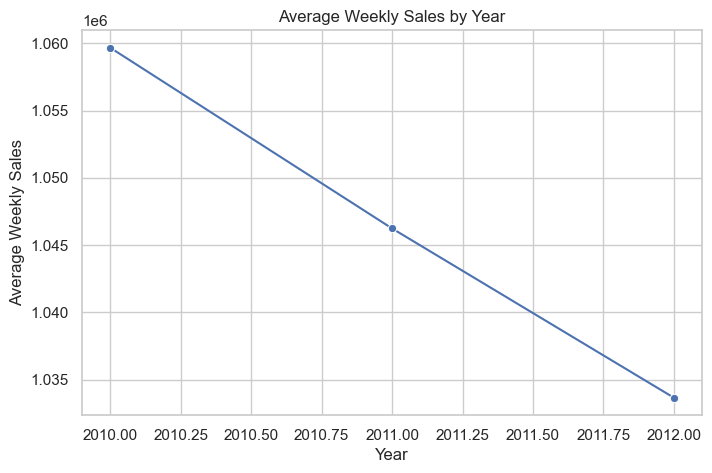

In [191]:
plt.figure(figsize=(8,5))

sns.lineplot(

    x=year_sales.index,

    y=year_sales.values,

    marker="o"

)

plt.title("Average Weekly Sales by Year")

plt.xlabel("Year")

plt.ylabel("Average Weekly Sales")

plt.show()

In [192]:
#Compare monthly sales during Holiday and Non-Holiday weeks.


monthly_holiday = pd.pivot_table(

    df,

    values="Weekly_Sales",

    index="Month",

    columns="Holiday_Flag",

    aggfunc="mean"

)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_holiday = monthly_holiday.reindex(month_order)

monthly_holiday

Holiday_Flag,0,1
Month,,
January,9.238846e+05,NaN
February,1.044557e+06,1.079128e+06
March,1.013309e+06,NaN
April,1.026762e+06,NaN
May,1.031714e+06,NaN
June,1.064325e+06,NaN
July,1.031748e+06,NaN
August,1.048017e+06,NaN
September,9.734078e+05,1.042427e+06


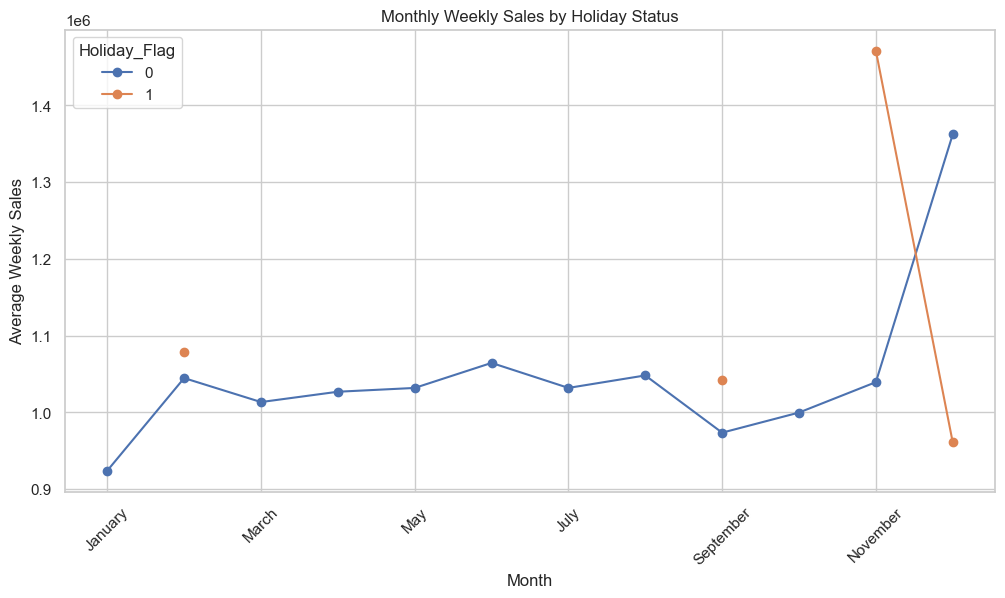

In [193]:
monthly_holiday.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Weekly Sales by Holiday Status")

plt.xlabel("Month")

plt.ylabel("Average Weekly Sales")

plt.xticks(rotation=45)

plt.show()

In [195]:
#Compare average sales across stores over different years.

store_year = pd.pivot_table(

    df,

    values="Weekly_Sales",

    index="Store",

    columns="Year",

    aggfunc="mean"

)

store_year.head()

Year,2010,2011,2012
Store,,,
1,1.526642e+06,1.556191e+06,1.586094e+06
2,1.984956e+06,1.896305e+06,1.895272e+06
3,3.905296e+05,4.003245e+05,4.191730e+05
4,1.993343e+06,2.136390e+06,2.157470e+06
5,3.090840e+05,3.167465e+05,3.295079e+05


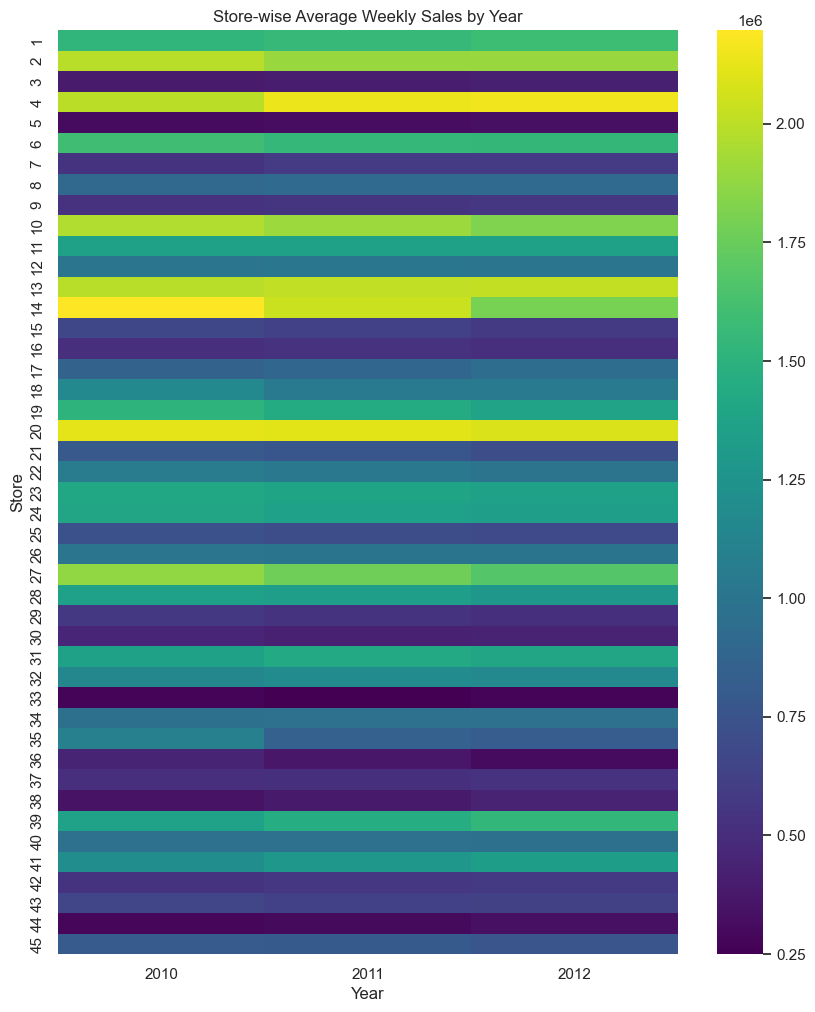

In [199]:
plt.figure(figsize=(10,12))

sns.heatmap(

    store_year,

    cmap="viridis"
    

)

plt.title("Store-wise Average Weekly Sales by Year")

plt.show()

## PART 7 : OUTLIER ANALYSIS
Objective

Identify extreme values (outliers) in numerical variables using boxplots and the Interquartile Range (IQR) method. Decide whether they should be removed based on business understanding.


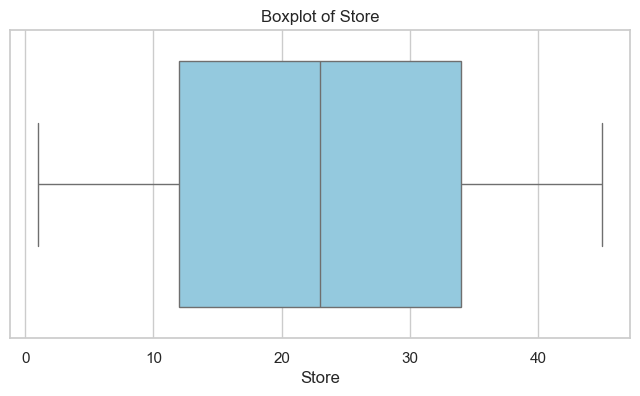

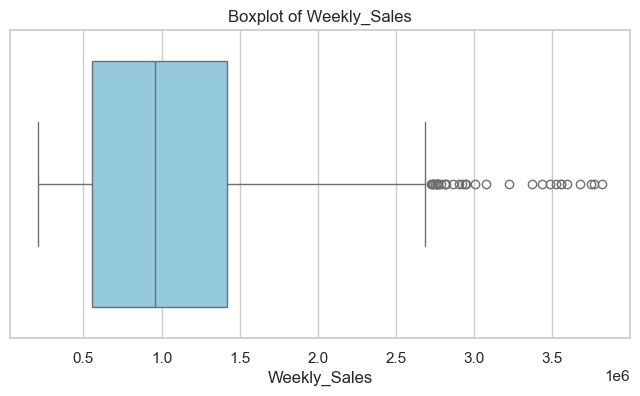

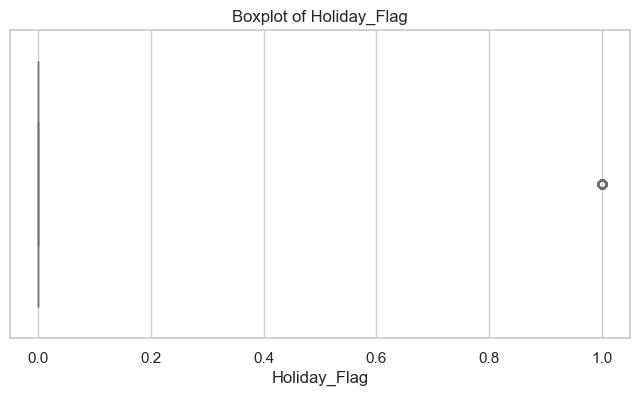

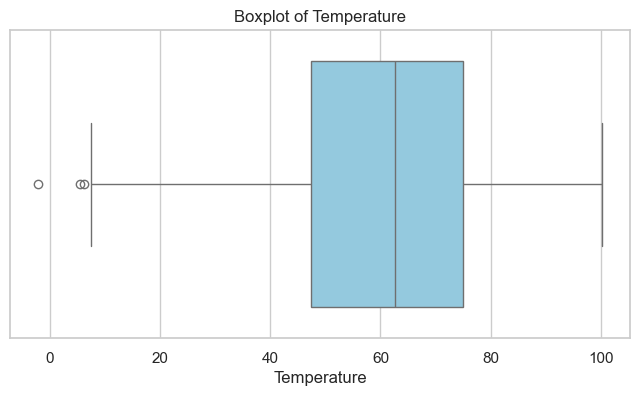

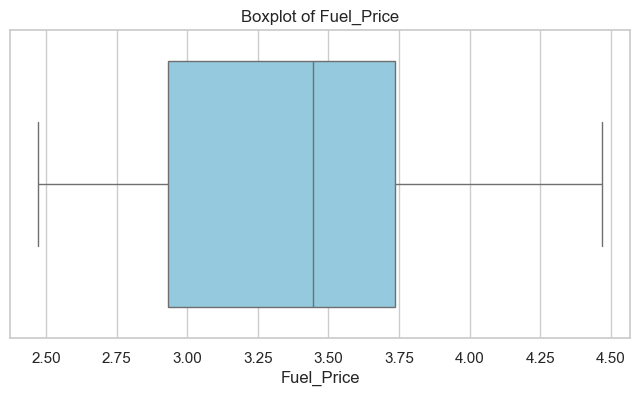

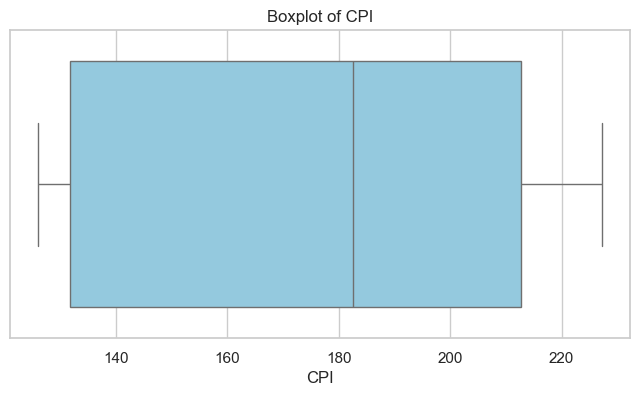

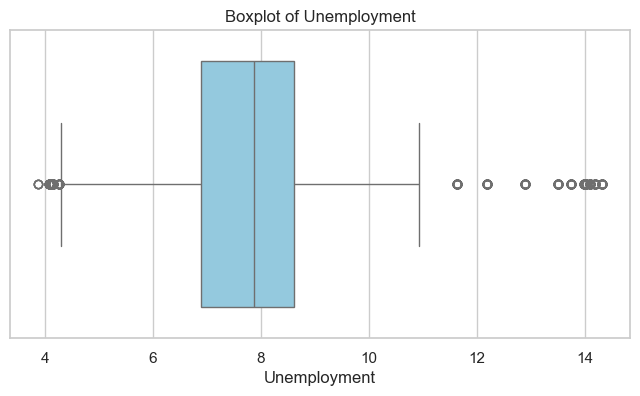

In [200]:
#Visualize outliers in all numerical columns using boxplots.


for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col], color="skyblue")

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()

In [201]:
#Detect outliers in each numerical feature using the IQR method.

outlier_summary = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

outlier_summary

{'Store': 0,
 'Weekly_Sales': 34,
 'Holiday_Flag': 450,
 'Temperature': 3,
 'Fuel_Price': 0,
 'CPI': 0,
 'Unemployment': 481}

In [202]:
#Create a summary table of outlier counts.

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Outlier_Count"]
)

outlier_df = outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

outlier_df

,Feature,Outlier_Count
6,Unemployment,481
2,Holiday_Flag,450
1,Weekly_Sales,34
3,Temperature,3
0,Store,0
4,Fuel_Price,0
5,CPI,0


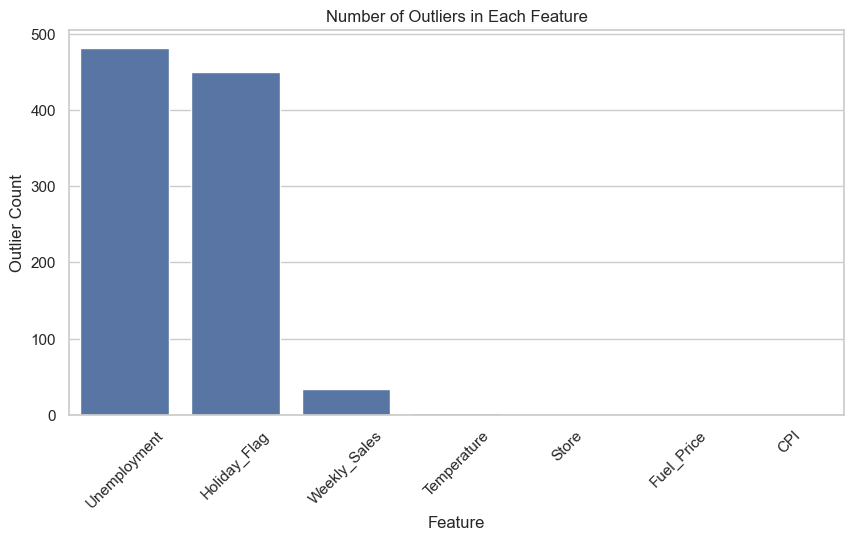

In [203]:
#Create a bar chart showing the number of outliers in each feature.

plt.figure(figsize=(10,5))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier_Count"
)

plt.xticks(rotation=45)

plt.title("Number of Outliers in Each Feature")

plt.xlabel("Feature")

plt.ylabel("Outlier Count")

plt.show()

In [204]:
outlier_summary = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Outlier_Count"]
)

outlier_df

,Feature,Outlier_Count
0,Store,0
1,Weekly_Sales,34
2,Holiday_Flag,450
3,Temperature,3
4,Fuel_Price,0
5,CPI,0
6,Unemployment,481


In [206]:
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

df_no_outliers = df[
    (df["Weekly_Sales"] >= lower) &
    (df["Weekly_Sales"] <= upper)
]

print("Original Shape :", df.shape)
print("After Removing Outliers :", df_no_outliers.shape)

Original Shape : (6435, 13)
After Removing Outliers : (6401, 13)


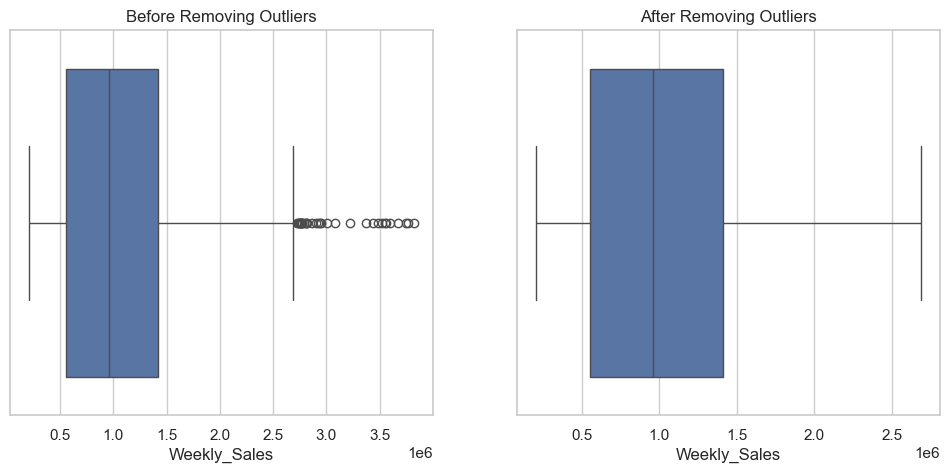

In [207]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(x=df["Weekly_Sales"])

plt.title("Before Removing Outliers")

plt.subplot(1,2,2)

sns.boxplot(x=df_no_outliers["Weekly_Sales"])

plt.title("After Removing Outliers")

plt.show()

In [208]:
df.shape

(6435, 13)

In [212]:
# Continuous numerical columns only
outlier_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

df_clean = df.copy()

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("Original Shape :", df.shape)
print("After Removing Outliers :", df_clean.shape)

Original Shape : (6435, 13)
After Removing Outliers : (5917, 13)


In [213]:
df_clean.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Week
count,5917.000000,5917,5.917000e+03,5917.000000,5917.000000,5917.000000,5917.000000,5917.000000,5917.000000,5917.000000,5917.0
mean,22.801251,2011-06-14 17:15:31.485550,1.039313e+06,0.069123,60.433407,3.340543,175.023148,7.722305,2010.959101,2.483184,25.800913
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,7.460000,2.472000,126.064000,4.308000,2010.000000,1.000000,1.0
25%,11.000000,2010-10-08 00:00:00,5.525292e+05,0.000000,46.980000,2.891000,132.767067,6.891000,2010.000000,2.000000,14.0
50%,22.000000,2011-06-10 00:00:00,9.472292e+05,0.000000,62.620000,3.420000,190.006988,7.852000,2011.000000,2.000000,26.0
75%,34.000000,2012-02-17 00:00:00,1.427624e+06,0.000000,74.730000,3.721000,213.799099,8.494000,2012.000000,3.000000,37.0
max,45.000000,2012-10-26 00:00:00,2.685352e+06,1.000000,100.140000,4.468000,227.232807,10.926000,2012.000000,4.000000,52.0
std,13.094060,NaN,5.519450e+05,0.253684,18.386455,0.458200,39.023139,1.243337,0.795111,1.066388,14.045441


In [214]:
outlier_summary = {}

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ]

    outlier_summary[col] = len(outliers)

pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Remaining_Outliers"]
)

,Feature,Remaining_Outliers
0,Weekly_Sales,0
1,Temperature,0
2,Fuel_Price,0
3,CPI,0
4,Unemployment,78


## PART 8 : FEATURE ENGINEERING
Objective

Create new features from existing columns to uncover hidden business insights and improve future predictive models.

## Suggested Feature Engineering (Professional)

### 1. Sales Category
Create a new feature by categorizing weekly sales into **Low**, **Medium**, and **High** groups. This simplifies sales analysis and helps identify different performance levels across stores.

---

### 2. Season Feature
Derive a **Season** feature from the month (Winter, Spring, Summer, Autumn). Seasonal information helps analyze customer buying behavior and identify seasonal sales trends.

---

### 3. Holiday Type
Convert the binary `Holiday_Flag` into descriptive labels such as **Holiday** and **Non-Holiday**. This improves readability and makes business reports easier to understand.

---

### 4. Economic Categories
Categorize economic indicators such as **Fuel Price**, **CPI**, and **Unemployment** into Low, Medium, and High levels. These engineered features make it easier to analyze how economic conditions affect weekly sales.

---

### 5. Store Performance Category
Classify stores into **High Performing**, **Average Performing**, and **Low Performing** based on their average weekly sales. This feature helps management identify top-performing stores and focus improvement efforts on underperforming locations.

## PART 9 : BUSINESS INSIGHTS

In [215]:
#Which store has the highest average weekly sales?
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

store_sales

print("Top Performing Store:", store_sales.idxmax())
print("Average Weekly Sales:", store_sales.max())

Top Performing Store: 20
Average Weekly Sales: 2107676.8703496503


In [216]:
#Which store has the lowest average weekly sales?
print("Lowest Performing Store:", store_sales.idxmin())
print("Average Weekly Sales:", store_sales.min())

Lowest Performing Store: 33
Average Weekly Sales: 259861.69202797202


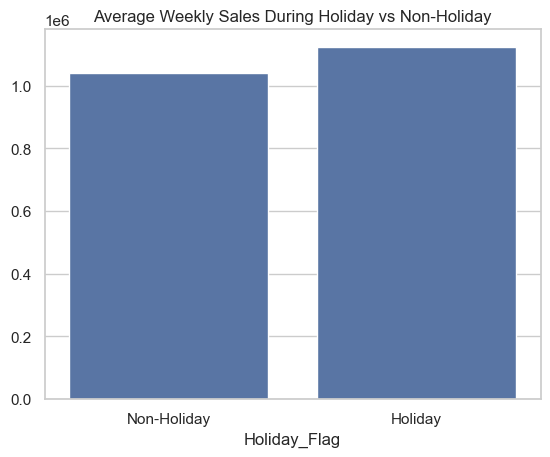

In [217]:
#Do holidays increase weekly sales?
holiday_sales = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .mean()
)

holiday_sales

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.xticks([0,1],["Non-Holiday","Holiday"])
plt.title("Average Weekly Sales During Holiday vs Non-Holiday")
plt.show()

In [218]:
#Which month has the highest average sales?
monthly_sales = (
    df.groupby("Month")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

monthly_sales

print("Highest Sales Month :", monthly_sales.idxmax())

Highest Sales Month : December


In [219]:
#Which quarter performs the best?
quarter_sales = (
    df.groupby("Quarter")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

quarter_sales

print("Best Quarter :", quarter_sales.idxmax())

Best Quarter : 4


In [220]:
#Which year records the highest sales?
year_sales = (
    df.groupby("Year")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

year_sales

print("Best Year :", year_sales.idxmax())

Best Year : 2010


In [221]:
#Which variables influence Weekly Sales the most?
sales_corr = (
    df.corr(numeric_only=True)["Weekly_Sales"]
      .sort_values(ascending=False)
)

sales_corr

Weekly_Sales    1.000000
Week            0.074211
Quarter         0.063363
Holiday_Flag    0.036891
Fuel_Price      0.009464
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64

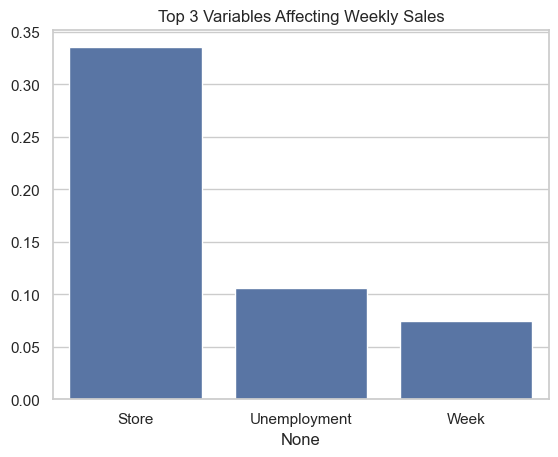

In [222]:
#op 3 variables affecting Weekly Sales
top3 = (
    sales_corr
    .drop("Weekly_Sales")
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

top3

sns.barplot(
    x=top3.index,
    y=top3.values
)

plt.title("Top 3 Variables Affecting Weekly Sales")
plt.show()

In [224]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Quarter', 'Week',
       'Day'],
      dtype='str')

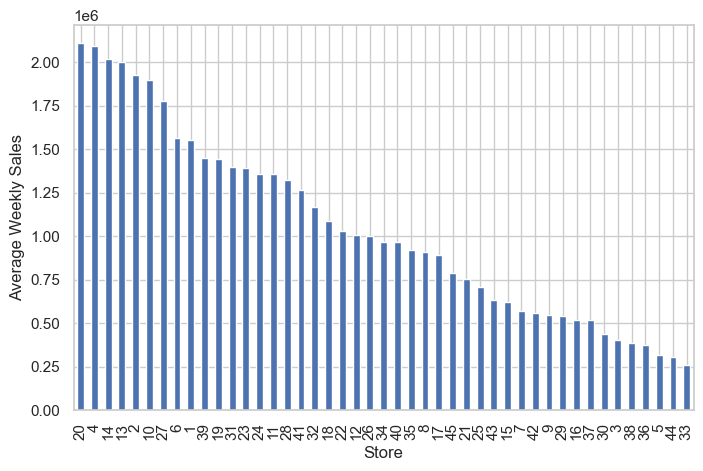

In [229]:
#Average sales by store
season_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

season_sales
plt.figure(figsize=(25,15))
season_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Weekly Sales")
plt.show()

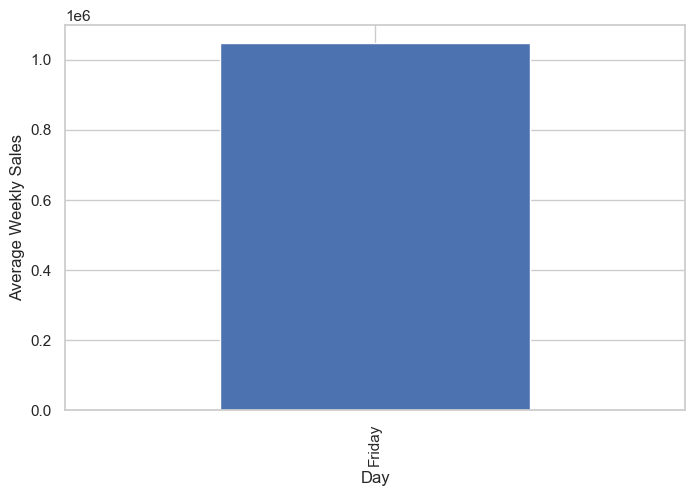

In [230]:
#Average sales by 
season_sales = (
    df.groupby("Day")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

season_sales

season_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Weekly Sales")
plt.show()

In [232]:
#Store Performance Ranking
ranking = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .rank(ascending=False)
)

ranking.sort_values()

Store
20     1.0
4      2.0
14     3.0
13     4.0
2      5.0
10     6.0
27     7.0
6      8.0
1      9.0
39    10.0
19    11.0
31    12.0
23    13.0
24    14.0
11    15.0
28    16.0
41    17.0
32    18.0
18    19.0
22    20.0
12    21.0
26    22.0
34    23.0
40    24.0
35    25.0
8     26.0
17    27.0
45    28.0
21    29.0
25    30.0
43    31.0
15    32.0
7     33.0
42    34.0
9     35.0
29    36.0
16    37.0
37    38.0
30    39.0
3     40.0
38    41.0
36    42.0
5     43.0
44    44.0
33    45.0
Name: Weekly_Sales, dtype: float64

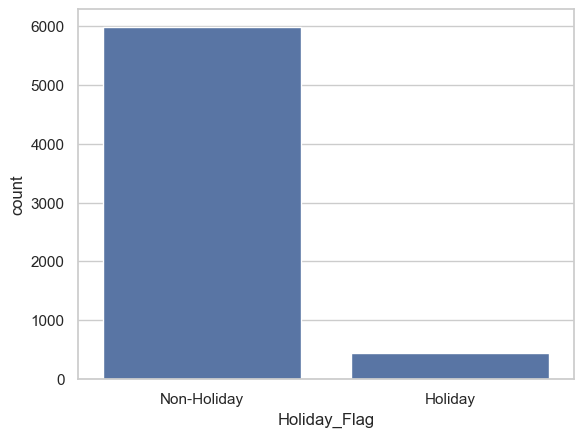

In [233]:
#Distribution of Holiday Weeks
df["Holiday_Flag"].value_counts()

sns.countplot(
    x="Holiday_Flag",
    data=df
)

plt.xticks([0,1],["Non-Holiday","Holiday"])

plt.show()

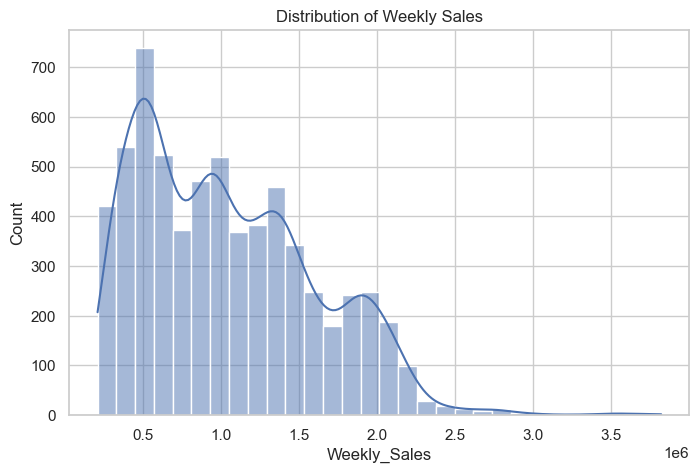

In [234]:
#Weekly Sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Weekly_Sales"],
    bins=30,
    kde=True
)

plt.title("Distribution of Weekly Sales")

plt.show()

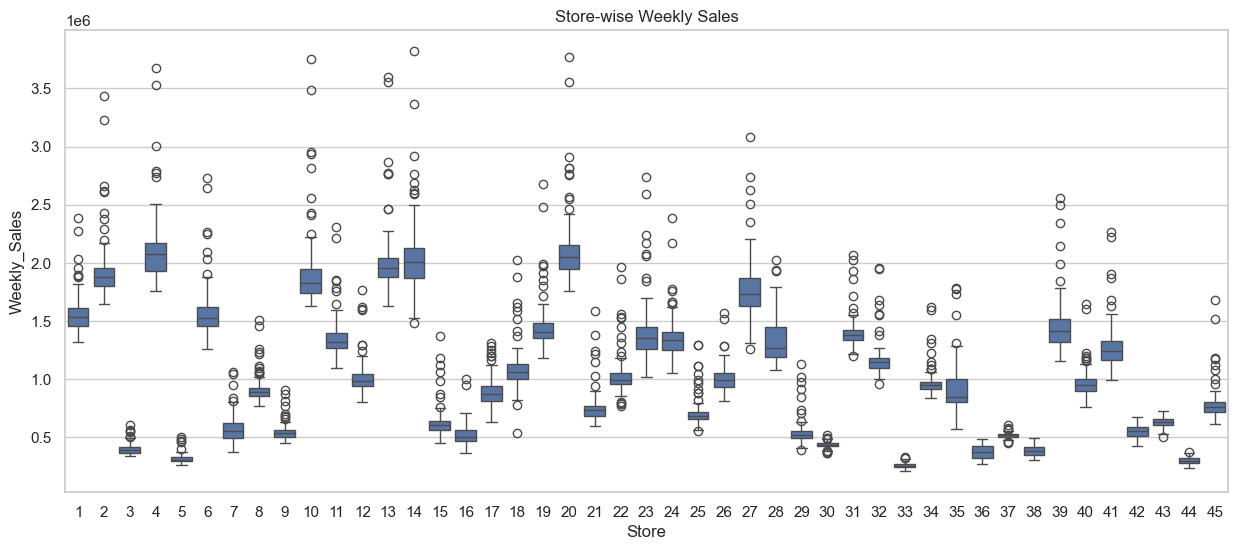

In [235]:
#Store-wise Sales Comparison
plt.figure(figsize=(15,6))

sns.boxplot(
    x="Store",
    y="Weekly_Sales",
    data=df
)

plt.title("Store-wise Weekly Sales")

plt.show()

In [236]:
#Overall Business Summary
summary = {
    "Total Stores": df["Store"].nunique(),
    "Total Records": len(df),
    "Average Weekly Sales": df["Weekly_Sales"].mean(),
    "Maximum Weekly Sales": df["Weekly_Sales"].max(),
    "Minimum Weekly Sales": df["Weekly_Sales"].min()
}

summary

{'Total Stores': 45,
 'Total Records': 6435,
 'Average Weekly Sales': np.float64(1046964.8775617715),
 'Maximum Weekly Sales': np.float64(3818686.45),
 'Minimum Weekly Sales': np.float64(209986.25)}

# 📘 PART 10 : BUSINESS RECOMMENDATIONS

## Recommendation 1: Focus on High-Performing Stores
Identify the stores with the highest average weekly sales and use their successful business strategies, inventory planning, and customer engagement practices as benchmarks for other stores.

---

## Recommendation 2: Improve Low-Performing Stores
Stores with consistently low weekly sales should be analyzed to identify operational issues. Targeted marketing campaigns, product assortment improvements, and local promotions can help increase their sales.

---

## Recommendation 3: Increase Inventory During Holiday Weeks
If the analysis shows higher sales during holiday periods, Walmart should maintain additional inventory and increase staff availability to avoid stock shortages and improve customer satisfaction.

---

## Recommendation 4: Use Seasonal Sales Trends for Planning
Analyze seasonal and monthly sales patterns to forecast product demand. Preparing inventory before peak seasons can reduce stock-outs and improve overall sales performance.

---

## Recommendation 5: Monitor Economic Indicators
Regularly monitor Fuel Price, CPI, and Unemployment because changes in these economic indicators may influence customer purchasing behavior and weekly sales performance.

---

## Recommendation 6: Strengthen Sales Forecasting
Use historical sales data together with features such as Month, Quarter, Season, and Holiday Flag to build accurate forecasting models for future sales planning.

---

## Recommendation 7: Optimize Inventory Management
Maintain sufficient inventory for products with consistently high demand while reducing excess stock during low-demand periods to minimize storage and operational costs.

---

## Recommendation 8: Implement Data-Driven Marketing Strategies
Marketing campaigns should be planned based on sales trends, seasonal demand, and holiday periods instead of applying the same promotional strategy throughout the year.

---

## Recommendation 9: Continuously Monitor Store Performance
Develop an interactive dashboard to monitor store-wise sales, monthly performance, holiday sales, and economic indicators so that management can quickly identify performance changes and take corrective actions.

---

## Recommendation 10: Develop Predictive Analytics Solutions
Build machine learning models using variables such as Temperature, Fuel Price, CPI, Unemployment, Holiday Flag, Month, Quarter, and Season to accurately predict future weekly sales and support strategic business decisions.

---
# 📘 FINAL CONCLUSION

## Conclusion

The Exploratory Data Analysis (EDA) of the Walmart Weekly Sales dataset provided a comprehensive understanding of sales patterns across different stores, time periods, and economic conditions. The analysis included data cleaning, missing value treatment, outlier analysis, univariate, bivariate, and multivariate analysis, along with feature engineering to improve data quality and interpretability.

The results revealed that weekly sales vary significantly across stores and time periods. Holiday weeks and seasonal trends play an important role in influencing sales performance, while economic indicators such as Fuel Price, CPI, and Unemployment also contribute to changes in customer purchasing behavior. Correlation analysis and visualizations helped identify the variables that have the greatest impact on weekly sales.

Overall, this project demonstrates how Exploratory Data Analysis can transform raw retail data into meaningful business insights. The findings can help Walmart improve inventory management, optimize marketing campaigns, enhance sales forecasting, and support data-driven business decision-making. The engineered features and analytical results also provide a strong foundation for developing future machine learning models for weekly sales prediction.